In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [85]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
# loading data
client_df = pd.read_csv('client_data (1).csv')
price_df = pd.read_csv('price_data (1).csv')
client_df = pd.DataFrame(client_df)
price_df = pd.DataFrame(price_df)
print(client_df.head(5))
print(price_df.head(5))

                                 id                     channel_sales  \
0  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1  d29c2c54acc38ff3c0614d0a653813dd                           MISSING   
2  764c75f661154dac3a6c254cd082ea7d  foosdfpfkusacimwkcsosbicdxkicaua   
3  bba03439a292a1e166f80264c16191cb  lmkebamcaaclubfxadlmueccxoimlema   
4  149d57cf92fc41cf94415803a877cb4b                           MISSING   

   cons_12m  cons_gas_12m  cons_last_month  date_activ    date_end  \
0         0         54946                0  2013-06-15  2016-06-15   
1      4660             0                0  2009-08-21  2016-08-30   
2       544             0                0  2010-04-16  2016-04-16   
3      1584             0                0  2010-03-30  2016-03-30   
4      4425             0              526  2010-01-13  2016-03-07   

  date_modif_prod date_renewal  forecast_cons_12m  ...  has_gas  imp_cons  \
0      2015-11-01   2015-06-23               0.00  ...        t

In [4]:
# convert str to date
date_cols = client_df[["date_activ", "date_end", "date_modif_prod", "date_renewal"]]

for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], format="%Y-%m-%d")

In [5]:
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format="%Y-%m-%d")


In [6]:
# data info and description
print(client_df.info())
print(price_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  str           
 1   channel_sales                   14606 non-null  str           
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[us]
 6   date_end                        14606 non-null  datetime64[us]
 7   date_modif_prod                 14606 non-null  datetime64[us]
 8   date_renewal                    14606 non-null  datetime64[us]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  forecast_disc

In [7]:
# data visualization
def plot_stacked_bars(dataframe, title_, size_=(18,10), rot_=0, legend_="lower right"):
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # annotate bars
    annotate_stacked_bars(ax, textsize=12)
    # rename legends
    plt.legend(["Retention", "Churn"], loc=legend_)
    plt.ylabel("Company base (%)")
    ax.tick_params(axis='x', labelsize=10)
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=10):
    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

### 1. Churn

In [8]:
churn = client_df[['id','churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
print(churn_total.transpose())
print(churn_percentage.transpose())

churn          0     1
Companies  13187  1419
churn              0         1
Companies  90.284814  9.715186


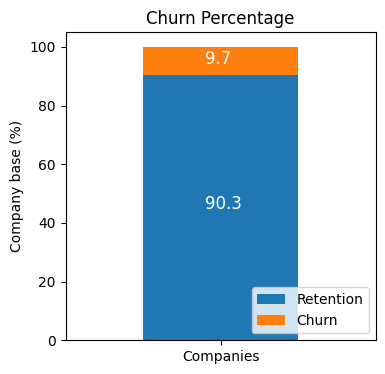

In [9]:
plot_stacked_bars(churn_percentage.transpose(), "Churn Percentage", (4, 4), 0, legend_="lower right")

About 10% of the customers churned

### Sales Channel

In [10]:
channel = client_df[['id', 'channel_sales', 'churn']]
channel = channel.groupby([channel['channel_sales'],channel['churn']])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
print(channel_churn)

churn                                      0          1
channel_sales                                          
foosdfpfkusacimwkcsosbicdxkicaua   87.859046  12.140954
usilxuppasemubllopkaafesmlibmsdf   89.963636  10.036364
ewpakwlliwisiwduibdlfmalxowmwpci   91.601344   8.398656
MISSING                            92.402685   7.597315
lmkebamcaaclubfxadlmueccxoimlema   94.411286   5.588714
epumfxlbckeskwekxbiuasklxalciiuu  100.000000   0.000000
fixdbufsefwooaasfcxdxadsiekoceaa  100.000000   0.000000
sddiedcslfslkckwlfkdpoeeailfpeds  100.000000   0.000000


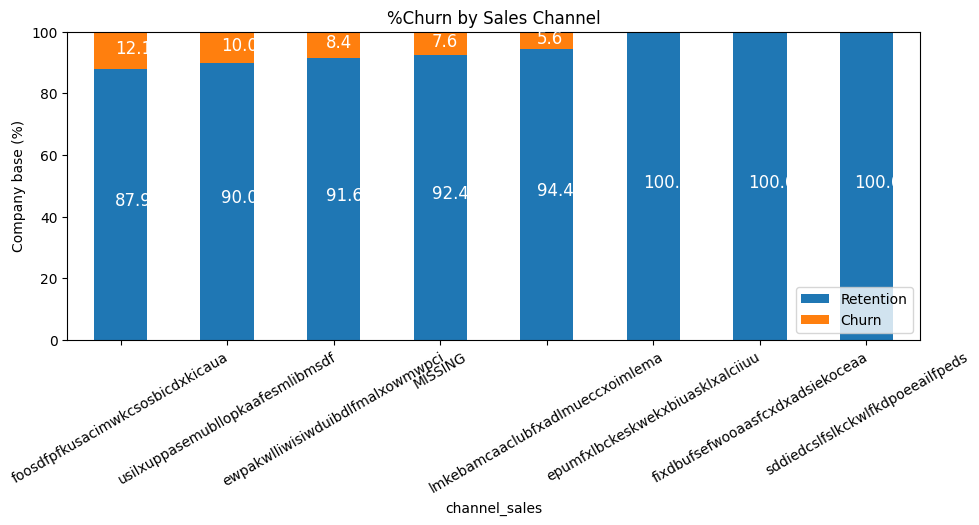

In [11]:
plot_stacked_bars(channel_churn, "%Churn by Sales Channel", size_=(11,4), rot_=30, legend_="lower right")

Interestingly, the churning customers are distributed over 5 different values for `channel_sales`. As well as this, the value of `MISSING` has a churn rate of 7.6%. `MISSING` indicates a missing value.

### Consumption

The following is the distribution of the consumption in the last year and month. Since the consumption data is univariate, it is best to use histograms to visualize their distribution.

In [12]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

In [13]:
def plot_distribution(dataframe, column, ax, bins_=50):
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

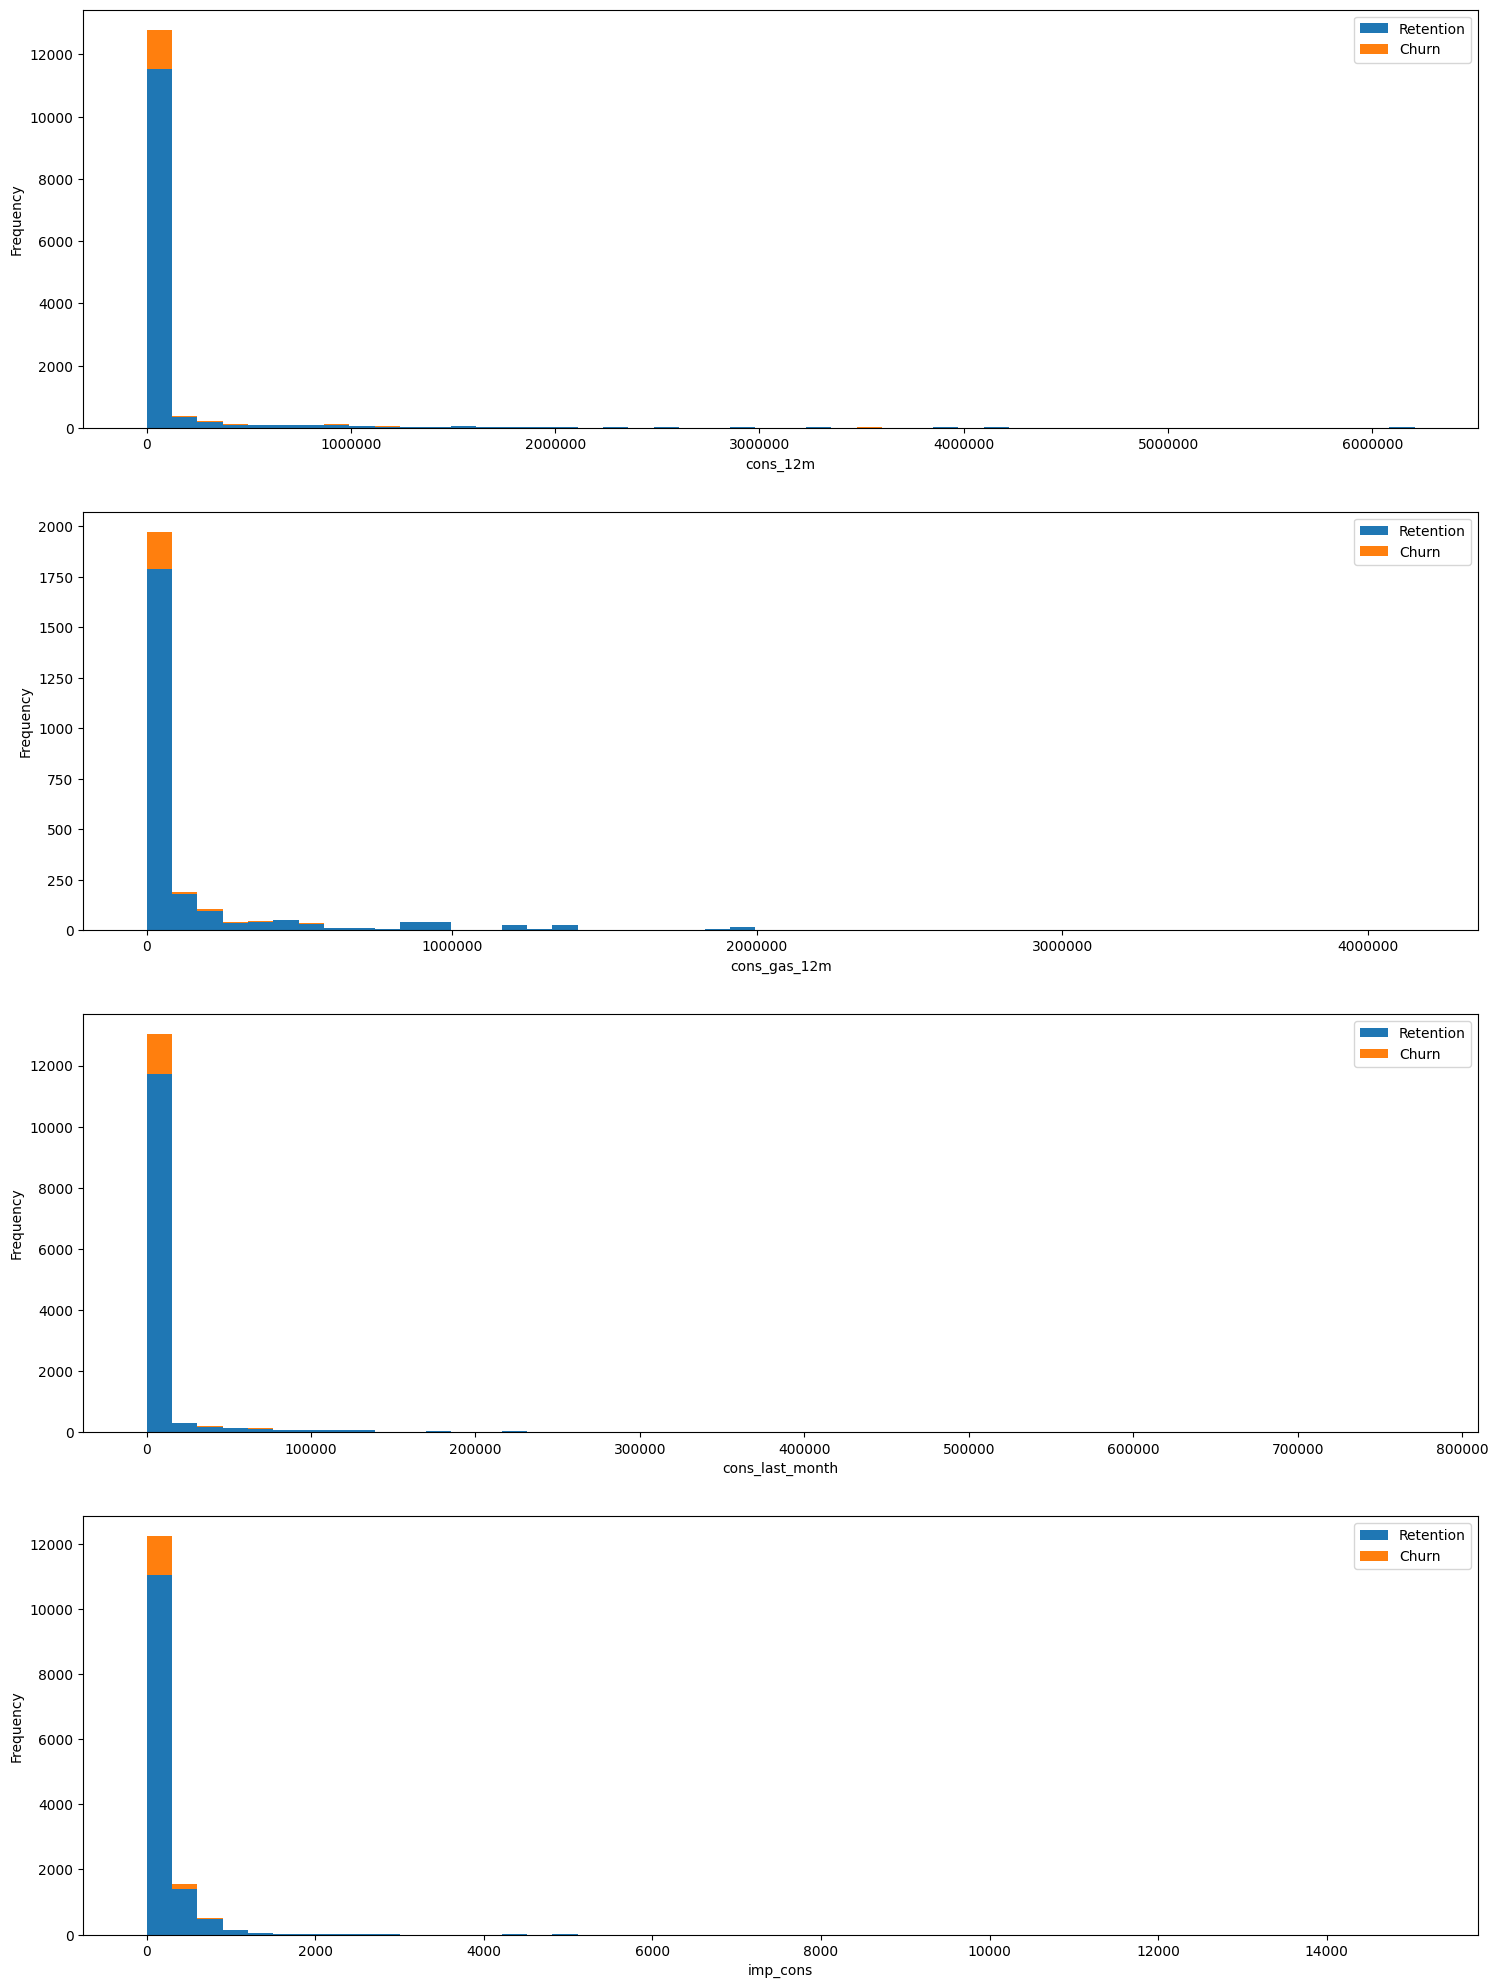

In [14]:
fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

plot_distribution(consumption, 'cons_12m', axs[0])
plot_distribution(consumption[consumption['has_gas'] == 't'], 'cons_gas_12m', axs[1])
plot_distribution(consumption, 'cons_last_month', axs[2])
plot_distribution(consumption, 'imp_cons', axs[3])

Clearly, the consumption data is highly positively skewed, presenting a very long right-tail towards the higher values of the distribution. The values on the higher and lower end of the distribution are likely to be outliers. Further detailed boxplot visualization is chosen to better understand the data distribution.

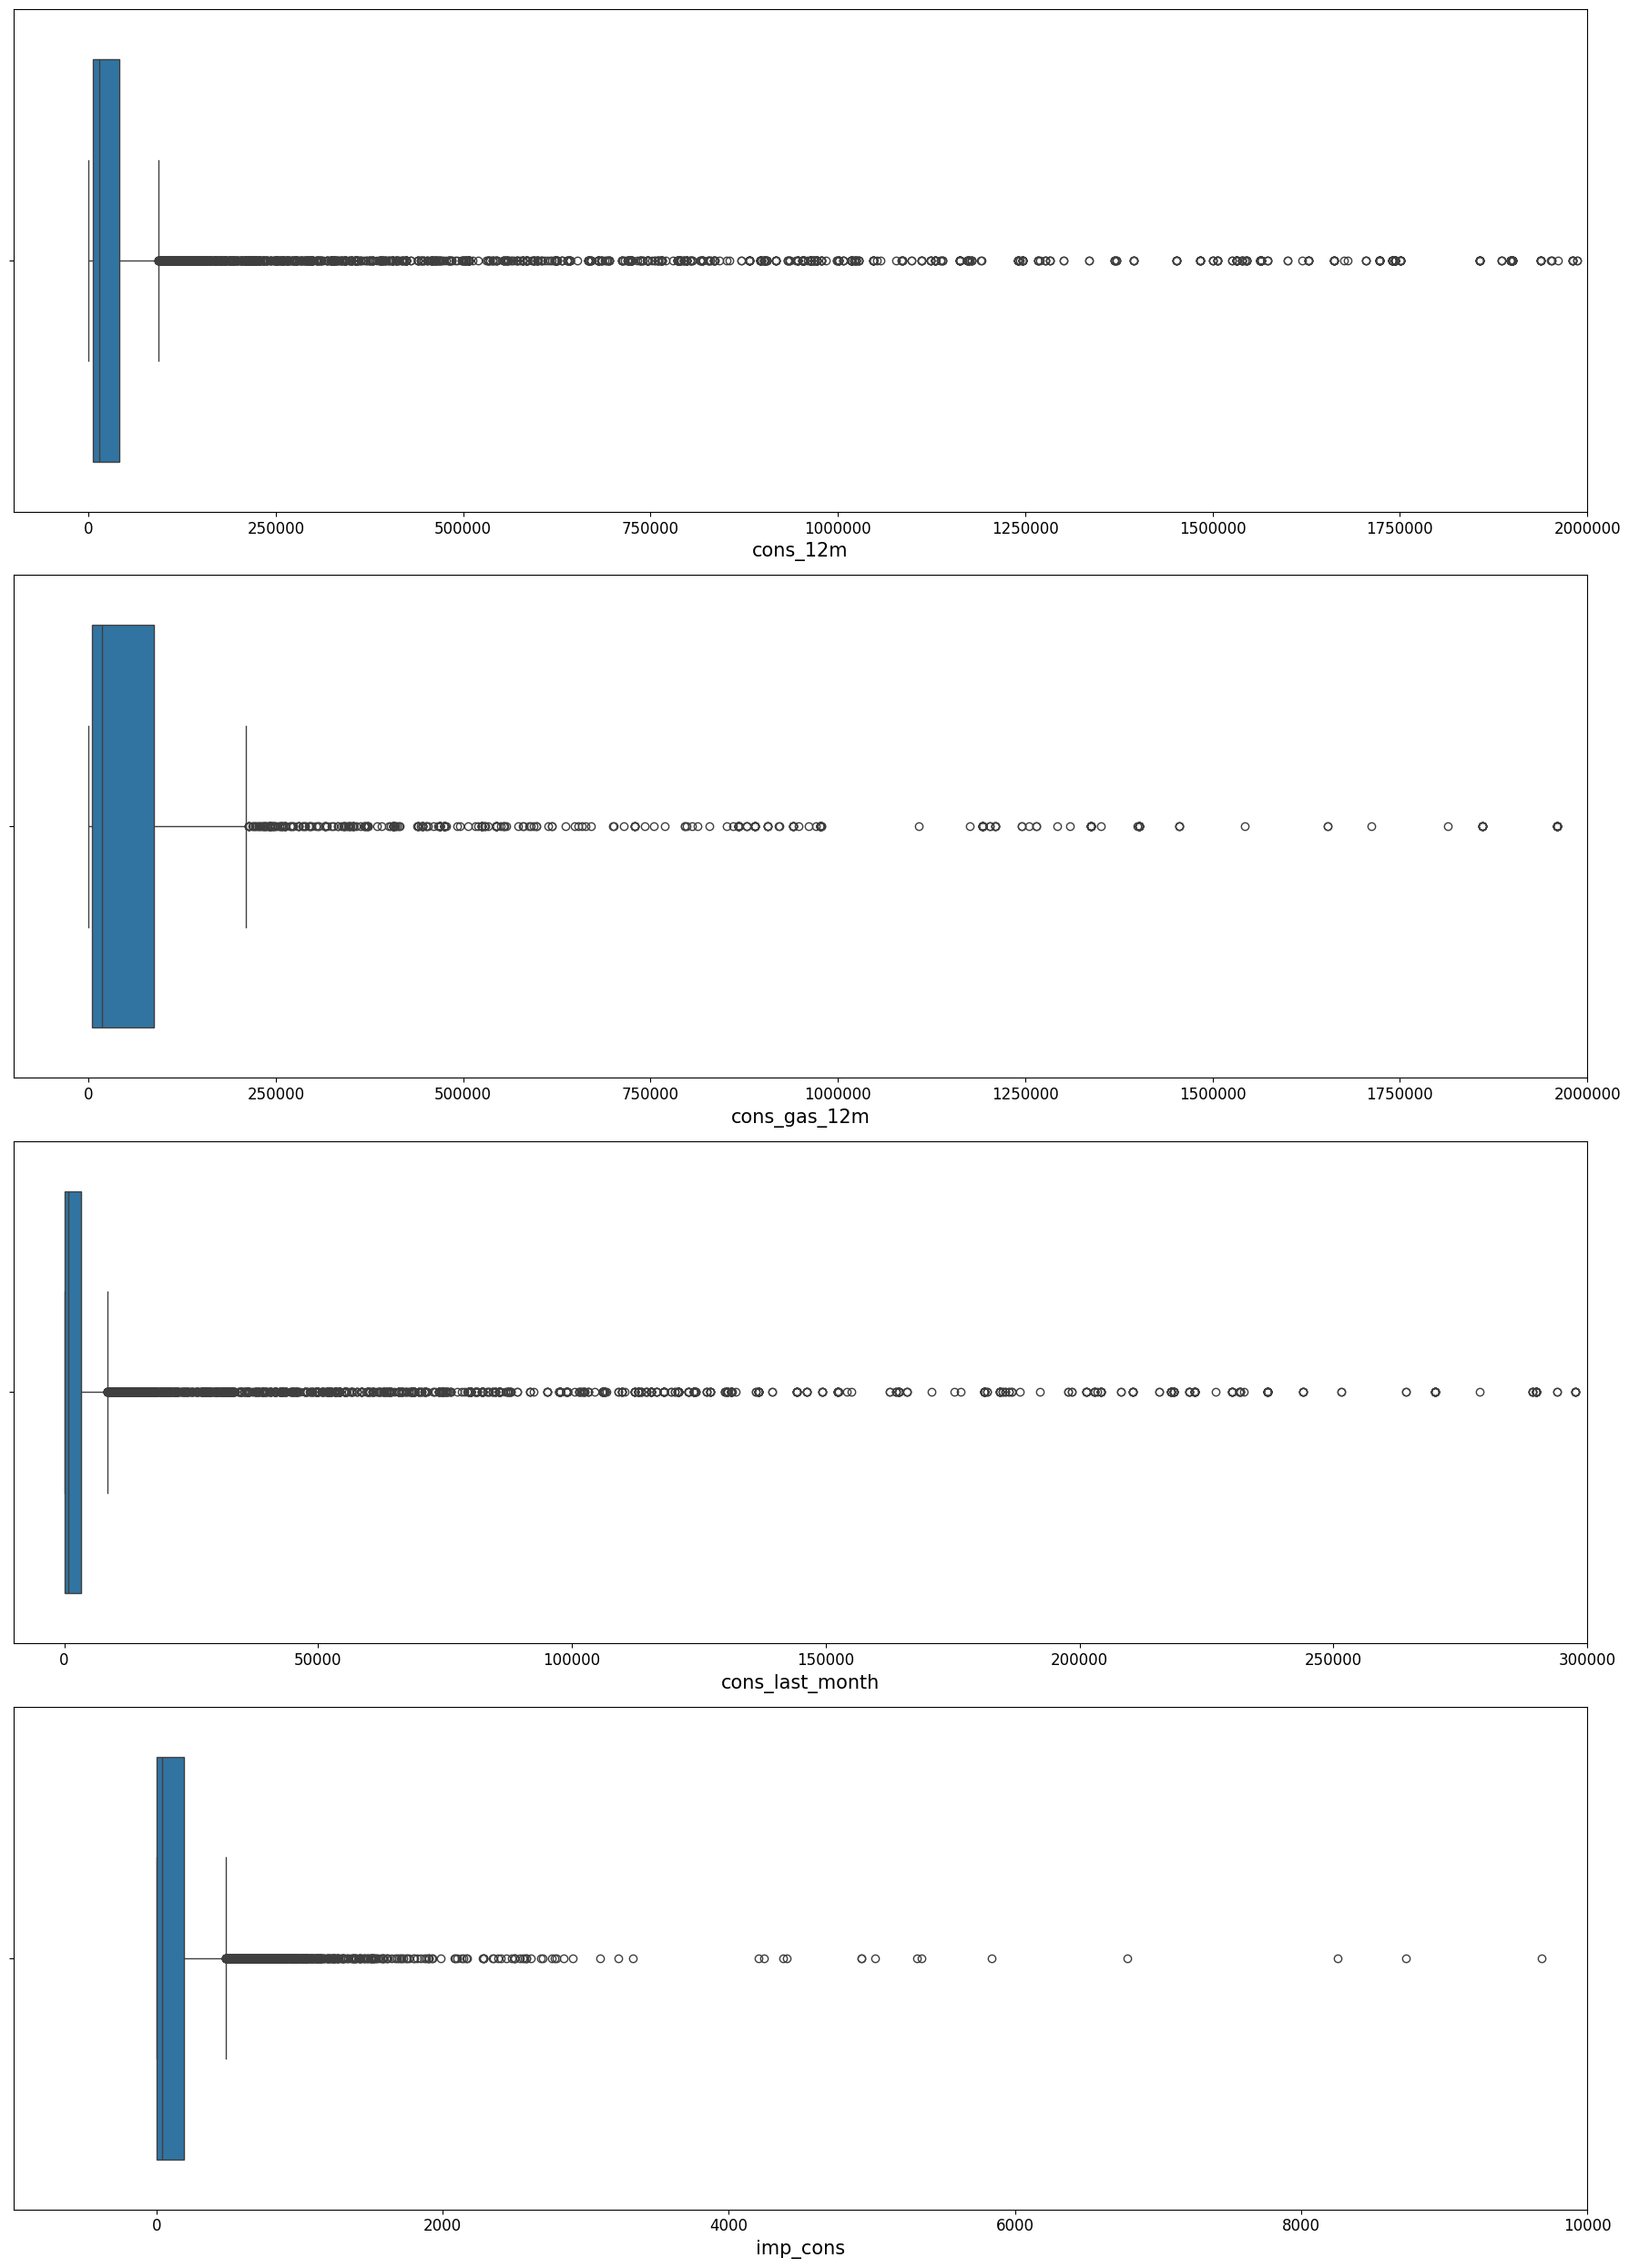

In [15]:
fig, axs = plt.subplots(nrows=4, figsize=(18,25))

sns.boxplot(x=consumption['cons_12m'], ax=axs[0])
sns.boxplot(x=consumption[consumption['has_gas'] == 't']['cons_gas_12m'], ax=axs[1])
sns.boxplot(x=consumption['cons_last_month'], ax=axs[2])
sns.boxplot(x=consumption['imp_cons'], ax=axs[3])

for ax in axs:
    ax.ticklabel_format(style='plain', axis='x')
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)

axs[0].set_xlim(-100000, 2000000)
axs[1].set_xlim(-100000, 2000000)
axs[2].set_xlim(-10000, 300000)
axs[3].set_xlim(-1000, 10000)

plt.tight_layout()
plt.show()

### Forecast

In [16]:
forecast = client_df[
    ['id', 'forecast_cons_12m', 'forecast_cons_year', 
     'forecast_discount_energy', 'forecast_meter_rent_12m', 
     'forecast_price_energy_off_peak', 'forecast_price_energy_peak',
     'forecast_price_pow_off_peak', 'churn']]
print(forecast.head())

                                 id  forecast_cons_12m  forecast_cons_year  \
0  24011ae4ebbe3035111d65fa7c15bc57               0.00                   0   
1  d29c2c54acc38ff3c0614d0a653813dd             189.95                   0   
2  764c75f661154dac3a6c254cd082ea7d              47.96                   0   
3  bba03439a292a1e166f80264c16191cb             240.04                   0   
4  149d57cf92fc41cf94415803a877cb4b             445.75                 526   

   forecast_discount_energy  forecast_meter_rent_12m  \
0                       0.0                     1.78   
1                       0.0                    16.27   
2                       0.0                    38.72   
3                       0.0                    19.83   
4                       0.0                   131.73   

   forecast_price_energy_off_peak  forecast_price_energy_peak  \
0                        0.114481                    0.098142   
1                        0.145711                    0.000000   

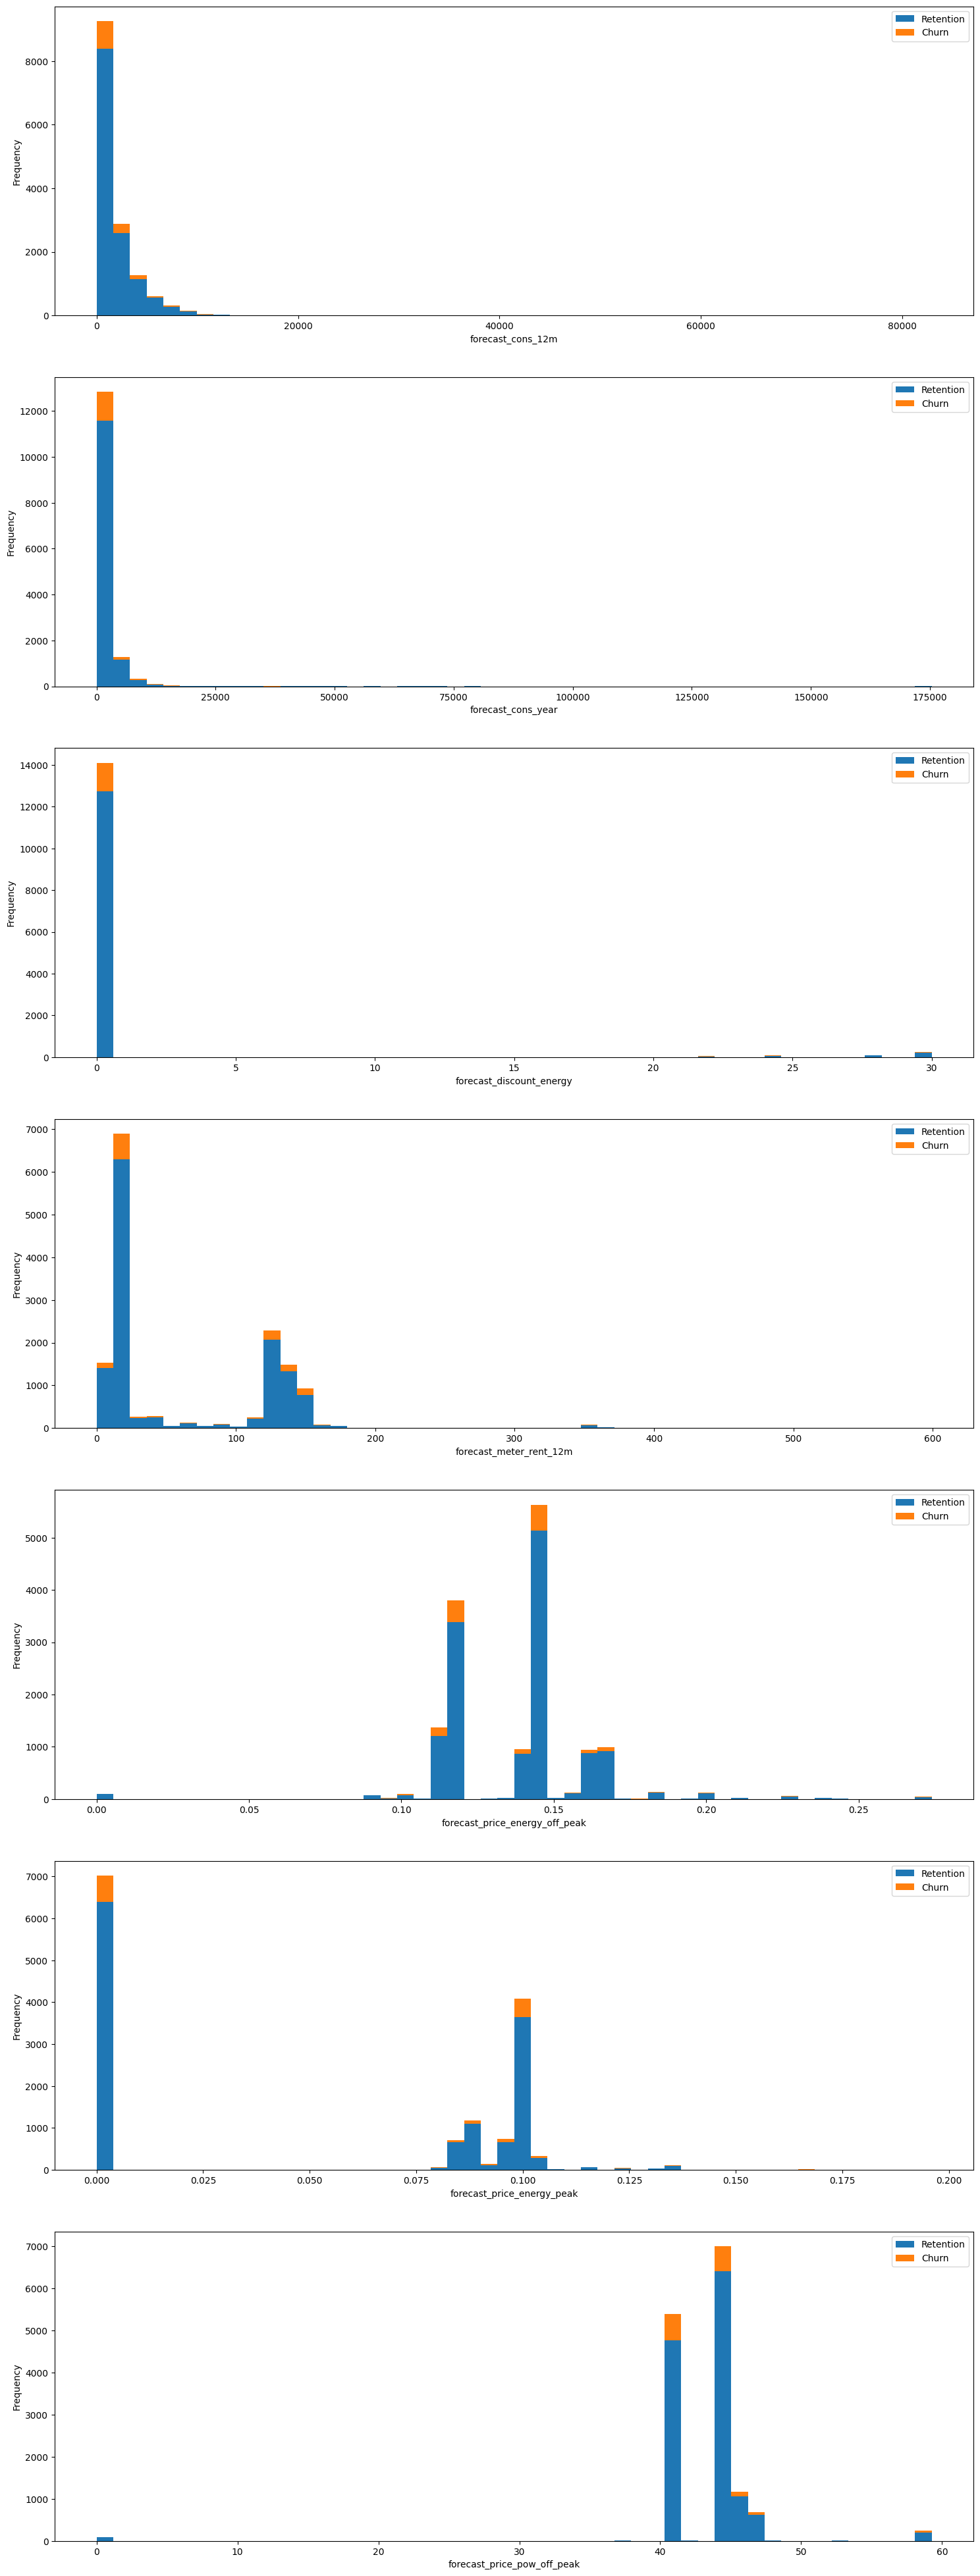

In [17]:
fig, axs = plt.subplots(nrows=7, figsize=(18,50))

plot_distribution(forecast, 'forecast_cons_12m', axs[0])
plot_distribution(forecast, 'forecast_cons_year', axs[1])
plot_distribution(forecast, 'forecast_discount_energy', axs[2])
plot_distribution(forecast, 'forecast_meter_rent_12m', axs[3])
plot_distribution(forecast, 'forecast_price_energy_off_peak', axs[4])
plot_distribution(forecast, 'forecast_price_energy_peak', axs[5])
plot_distribution(forecast, 'forecast_price_pow_off_peak', axs[6])

Similarly to the consumption plots, we can observe that a lot of the variables are highly positively skewed, creating a very long tail for the higher values.

### Contract Type

In [18]:
contract_type = client_df[['id', 'has_gas', 'churn']]
contract = contract_type.groupby([contract_type['churn'], contract_type['has_gas']])['id'].count().unstack(level=0)
contract_percentage = (contract.div(contract.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
print(contract_percentage)

churn            0          1
has_gas                      
f        89.945629  10.054371
t        91.814410   8.185590


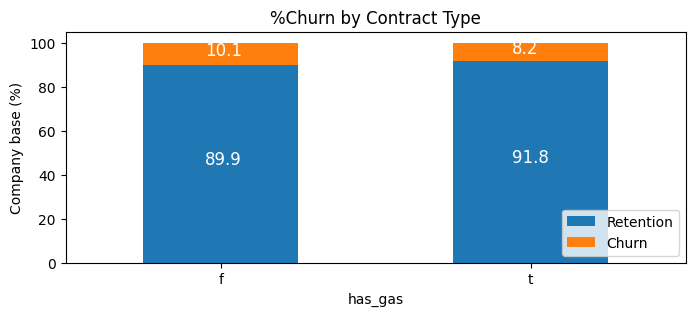

In [19]:
plot_stacked_bars(contract_percentage, '%Churn by Contract Type', (8,3))

### Margins

In [20]:
margin = client_df[['id', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']]

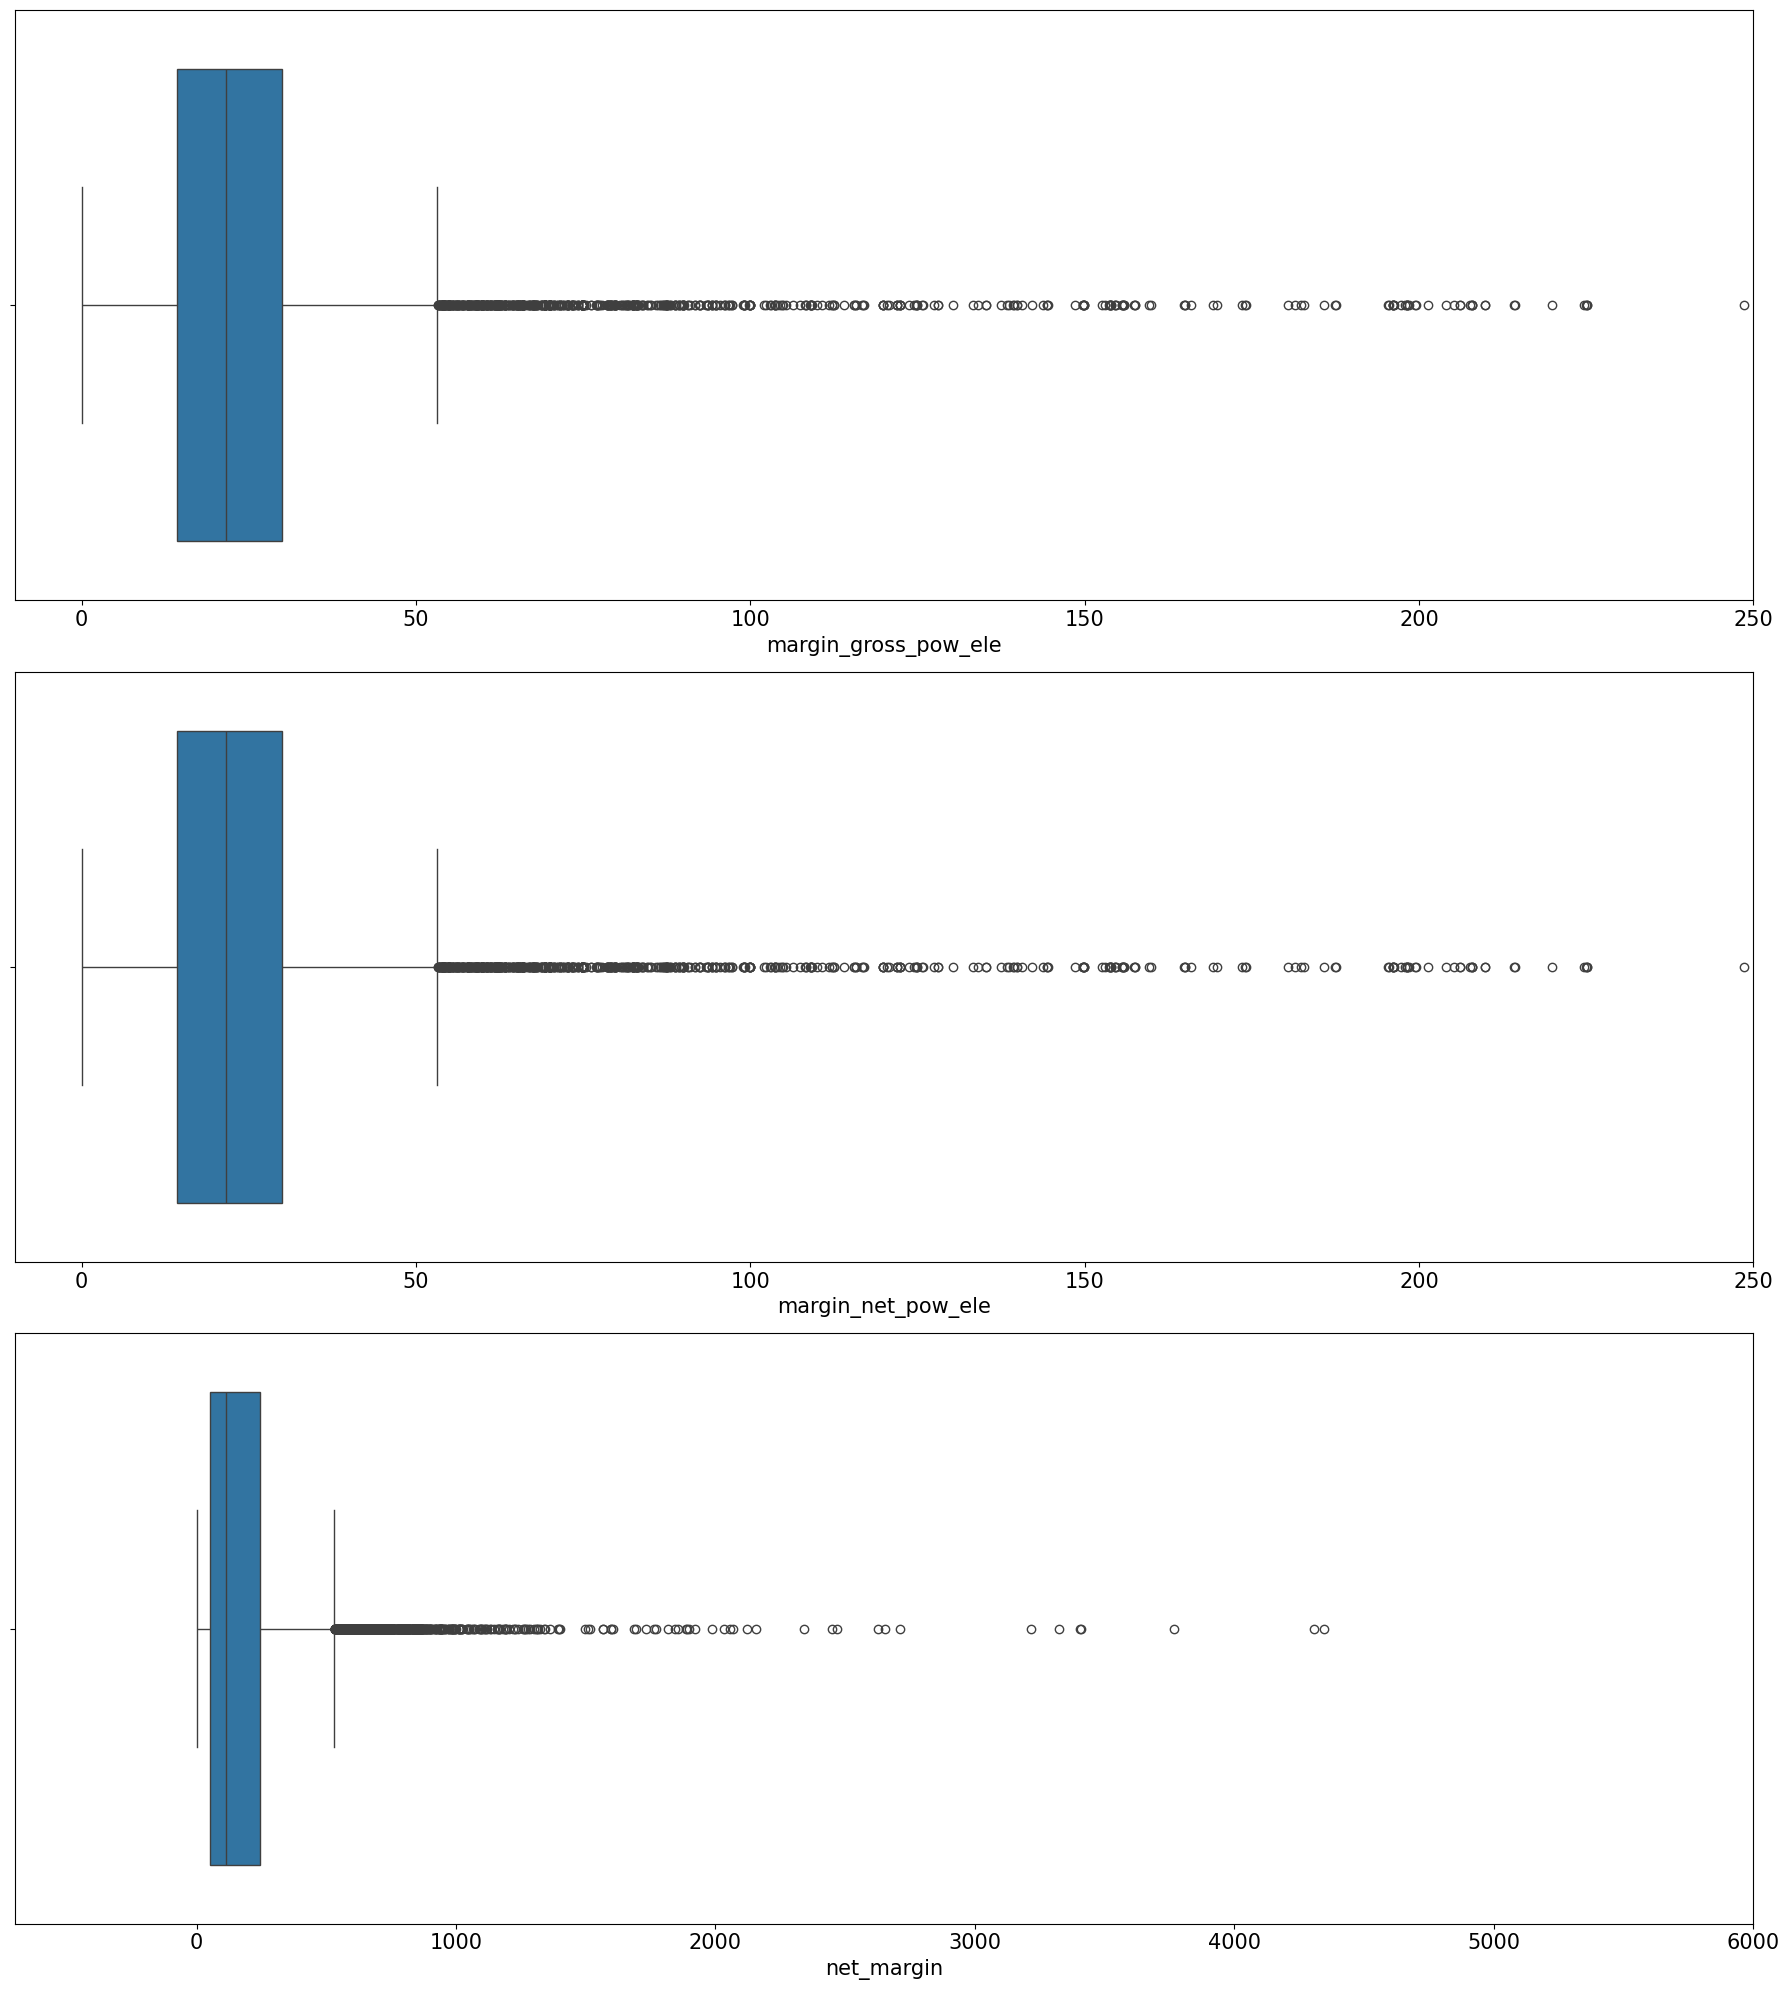

In [21]:
fig, axs = plt.subplots(nrows=3, figsize=(18,20))
sns.boxplot(x=margin['margin_gross_pow_ele'], ax=axs[0])
sns.boxplot(x=margin['margin_net_pow_ele'], ax=axs[1])
sns.boxplot(x=margin['net_margin'], ax=axs[2])

for ax in axs:
    ax.ticklabel_format(style='plain', axis='x')
    ax.tick_params(axis='both', labelsize=15)
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)

axs[0].set_xlim(-10, 250)
axs[1].set_xlim(-10, 250)
axs[2].set_xlim(-700, 6000)

plt.tight_layout()
plt.show()

### Subscribed Power

In [22]:
power = client_df[['id', 'pow_max', 'churn']]

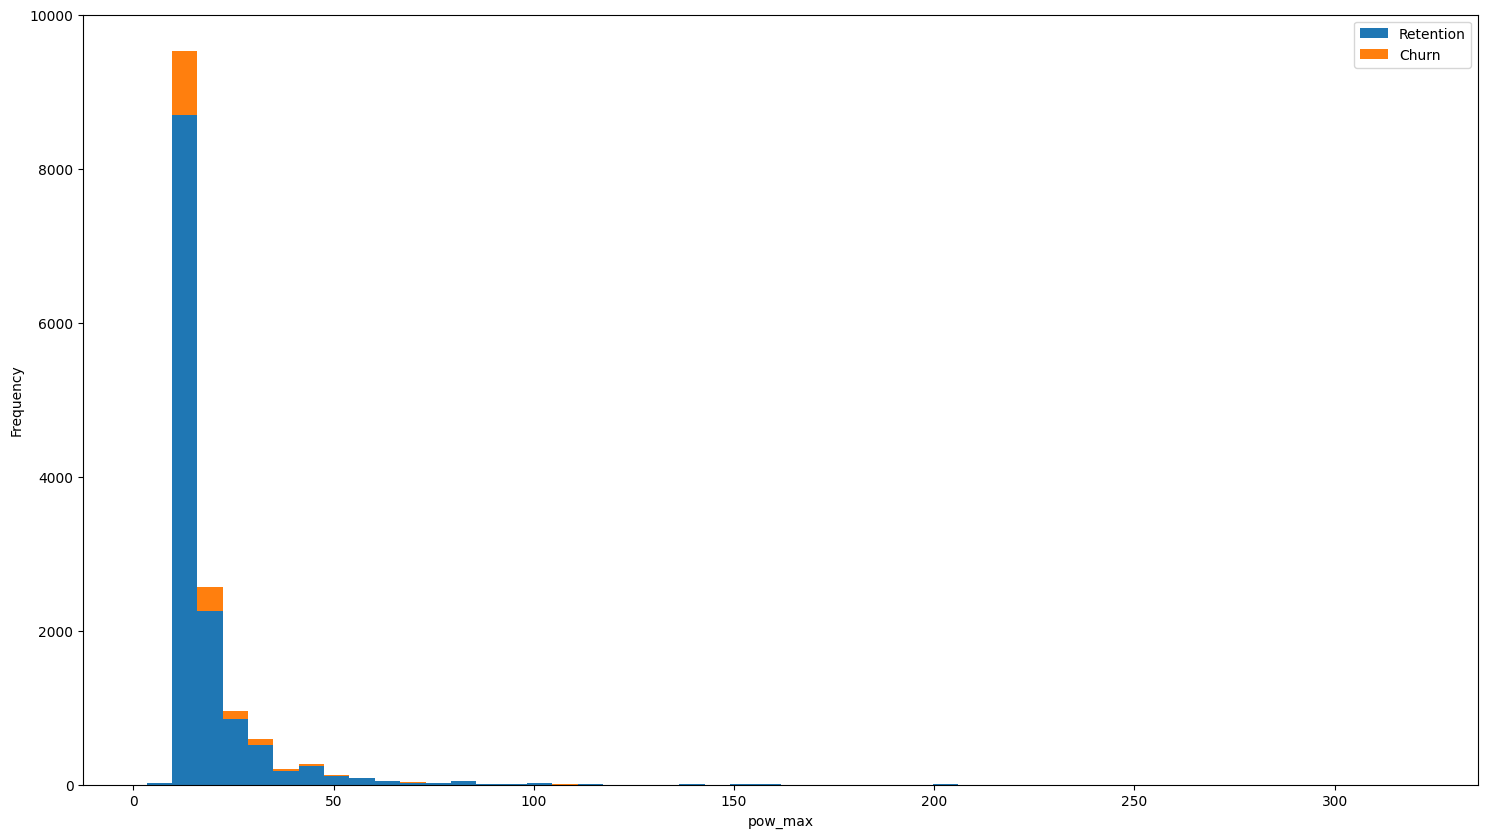

In [23]:
fig, axs = plt.subplots(nrows=1, figsize=(18,10))
plot_distribution(power, 'pow_max', axs)

### Numbers of Products, Clients Antiquity, and First Contract Subscribed

In [24]:
others = client_df[['id', 'nb_prod_act', 'num_years_antig', 'origin_up', 'churn']]
products = others.groupby([others['nb_prod_act'], others['churn']])['id'].count().unstack(level=1).fillna(0)
products_percentage = (products.div(products.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
print(products_percentage)

churn                 0          1
nb_prod_act                       
4             90.000000  10.000000
1             90.018371   9.981629
3             90.057361   9.942639
5             90.322581   9.677419
2             91.492843   8.507157
6            100.000000   0.000000
8            100.000000   0.000000
9            100.000000   0.000000
10           100.000000   0.000000
32           100.000000   0.000000


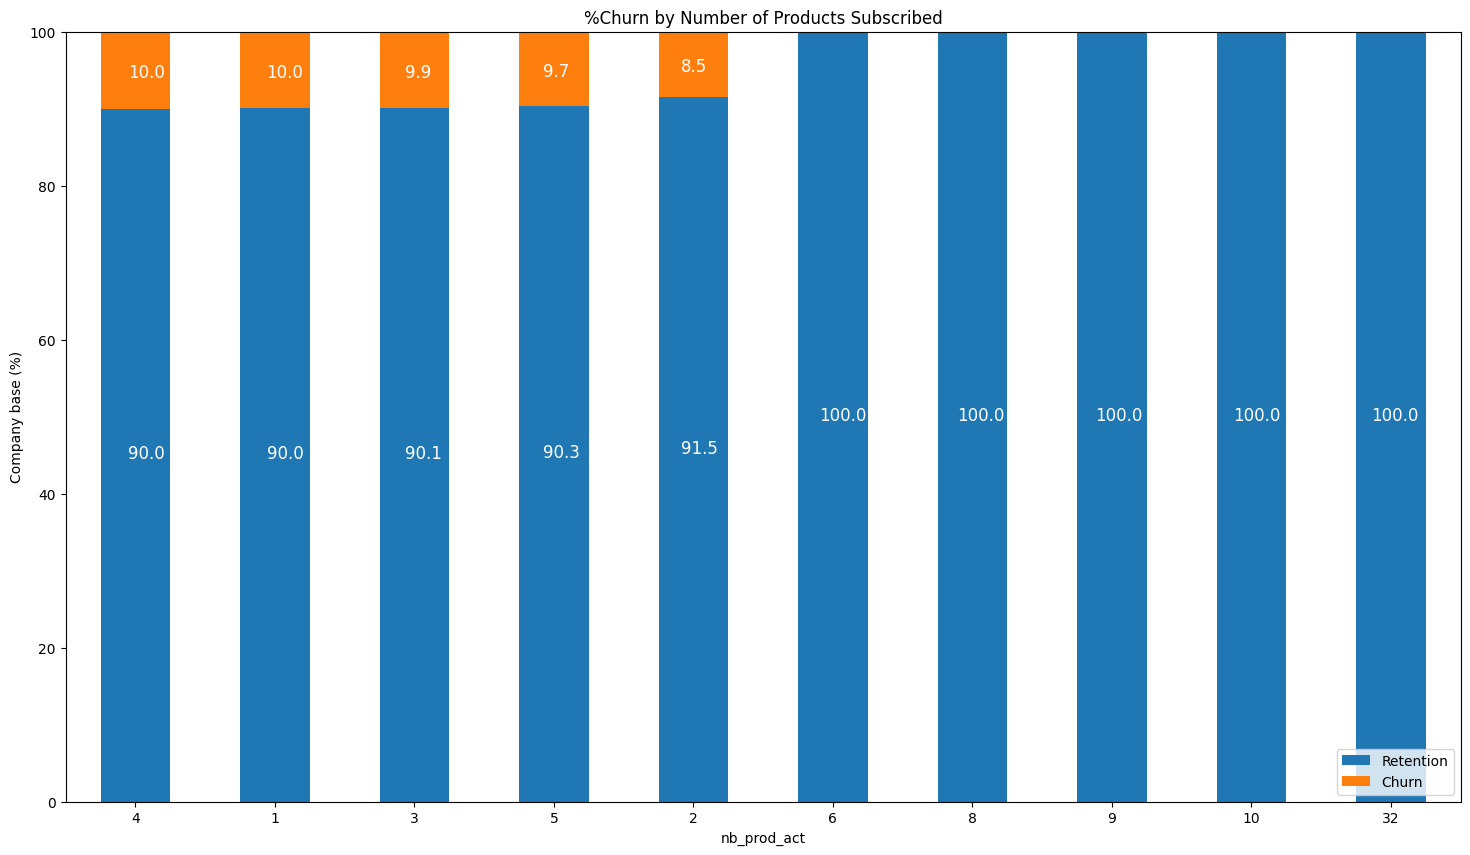

In [25]:
plot_stacked_bars(products_percentage, '%Churn by Number of Products Subscribed')


Customers subscribed to 6 products or more tend to not churn.

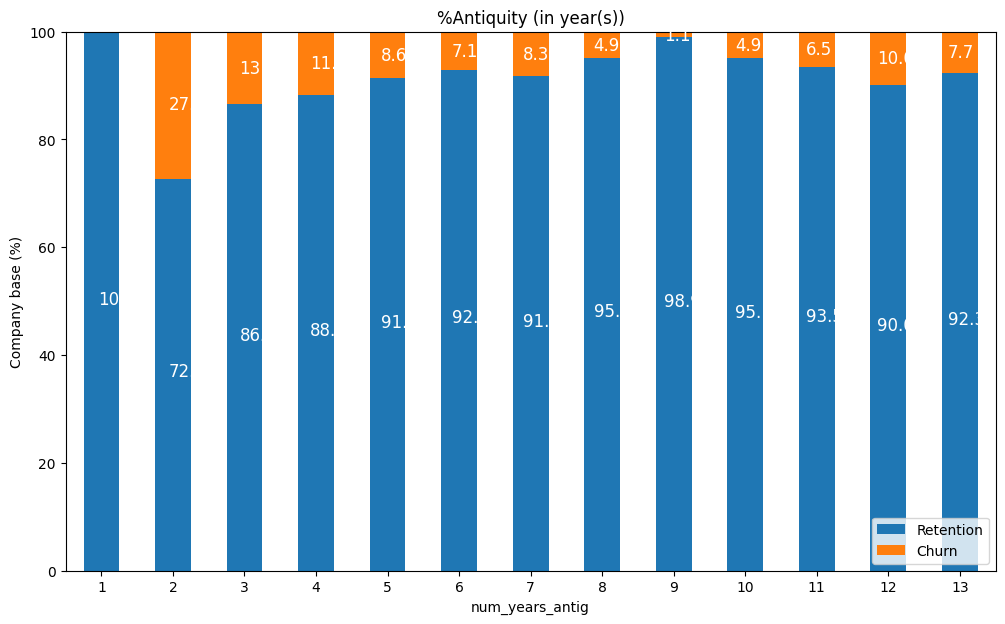

In [26]:
years_antig = others.groupby([others['num_years_antig'], others['churn']])['id'].count().unstack(level=1).fillna(0)
percent_years_antig = (years_antig.div(years_antig.sum(axis=1), axis=0) * 100)
plot_stacked_bars(percent_years_antig, '%Antiquity (in year(s))', (12,7))

Churning occurs most for customers who have subscribed for 2 to 4 years, as well as ones who retained for 12 years above. The spike at year 2 suggests this may be a critical decision point, customers who survive their first 1–2 years but haven't yet built deeper loyalty may be more likely to leave (e.g., contract renewal period, end of introductory offers/pricing).

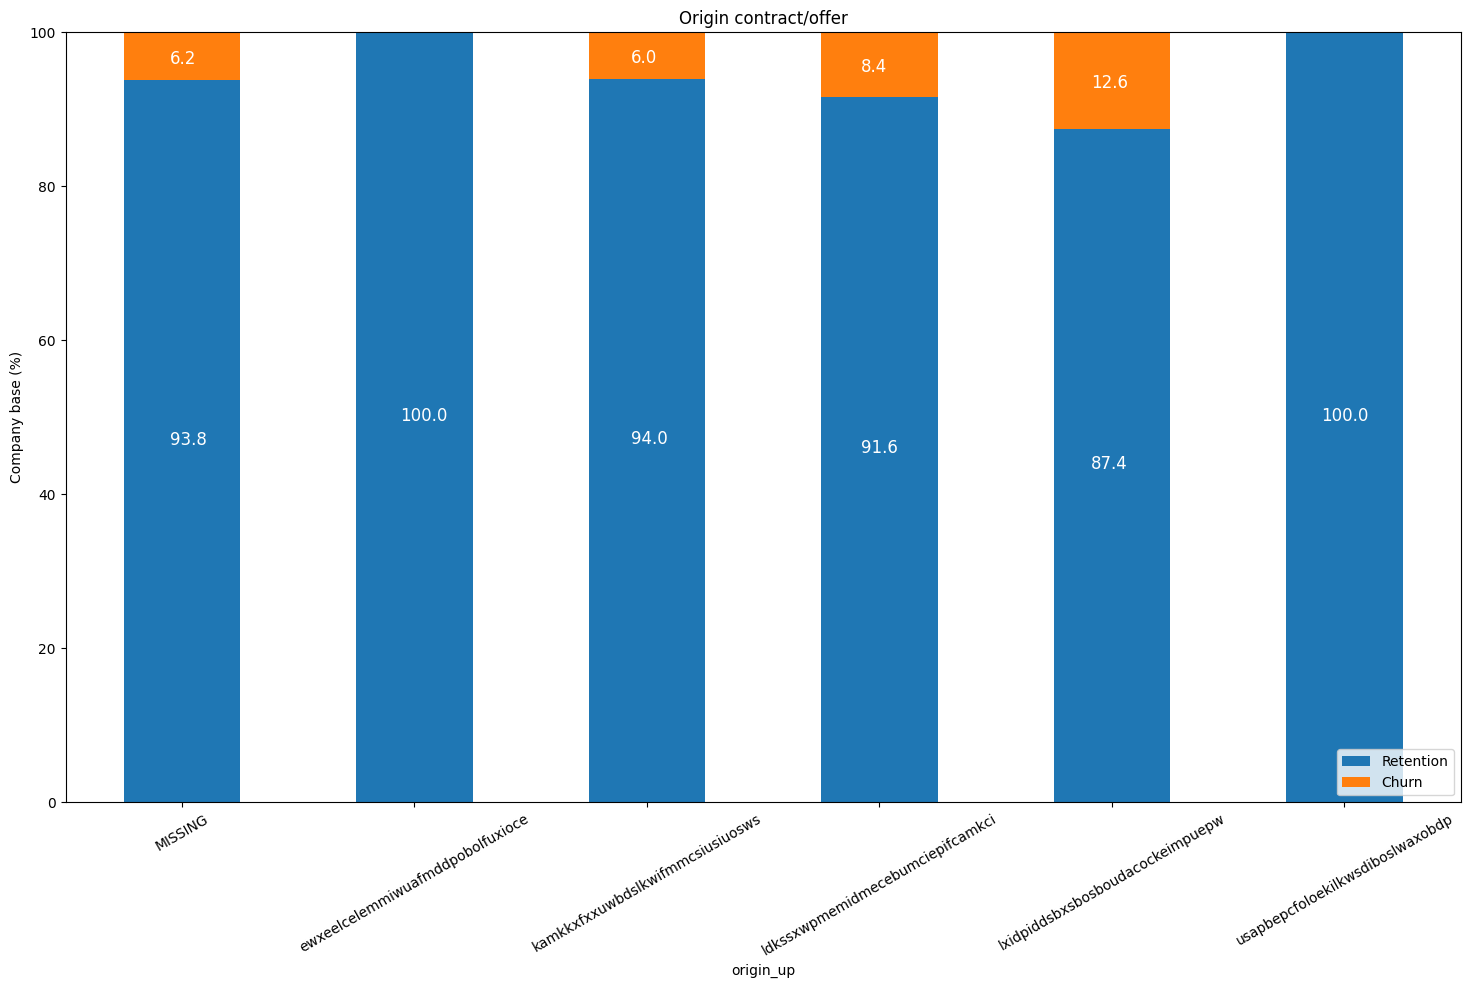

churn                                  0      1
origin_up                                      
MISSING                             60.0    4.0
ewxeelcelemmiwuafmddpobolfuxioce     1.0    0.0
kamkkxfxxuwbdslkwifmmcsiusiuosws  4036.0  258.0
ldkssxwpmemidmecebumciepifcamkci  2884.0  264.0
lxidpiddsbxsbosboudacockeimpuepw  6204.0  893.0
usapbepcfoloekilkwsdiboslwaxobdp     2.0    0.0


In [27]:
origin = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1).fillna(0)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stacked_bars(origin_percentage, "Origin contract/offer", rot_=30)
print(origin)

Customers starting at certain contracts tend to churn more than the others.
- The origin of a customer's contract matters, different acquisition channels/offers attract customers with different loyalty profiles.
- The high-churn origin (lxdpdddsbobsboudacockeimpuepw) at 12.6% is worth investigating: Was this a discounted offer? A specific campaign? Customers acquired through heavy discounts often churn once the discount ends.
- The 0% churn origins may indicate simply very small sample sizes.

### Price Trend

In [28]:
price_df.sort_index(ascending=False).head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
193001,16f51cdc2baa19af0b940ee1b3dd17d5,2015-12-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
193000,16f51cdc2baa19af0b940ee1b3dd17d5,2015-11-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192999,16f51cdc2baa19af0b940ee1b3dd17d5,2015-10-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192998,16f51cdc2baa19af0b940ee1b3dd17d5,2015-09-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192997,16f51cdc2baa19af0b940ee1b3dd17d5,2015-08-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555


In [29]:
# Monthly off-peak-prices by companies and month
monthly_price = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'})

# Get dec and jan prices (energy and power)
jan_prices = monthly_price.groupby('id').first().reset_index()
dec_prices = monthly_price.groupby('id').last().reset_index()

# Calculate the difference for energy and power prices
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_energy', 'price_off_peak_fix': 'dec_power'}), jan_prices.rename(columns={'price_off_peak_var': 'jan_energy', 'price_off_peak_fix': 'jan_power'}), on='id')
diff['offpeak_diff_dec_jan_energy'] = diff['dec_energy'] - diff['jan_energy']
diff['offpeak_diff_dec_jan_power'] = diff['dec_power'] - diff['jan_power']
diff_df = diff[['id', 'offpeak_diff_dec_jan_energy', 'offpeak_diff_dec_jan_power']]
diff_df.head()

,id,offpeak_diff_dec_jan_energy,offpeak_diff_dec_jan_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


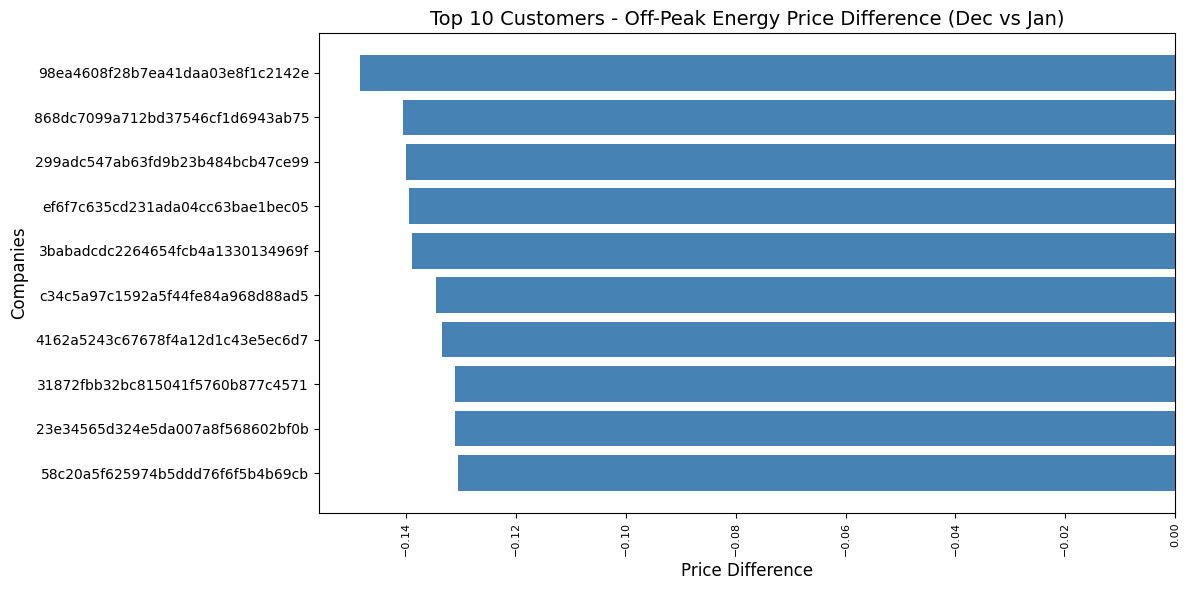

In [30]:
# Top 10 customers by highest energy price difference
top10 = diff_df.nsmallest(10, 'offpeak_diff_dec_jan_energy').sort_values('offpeak_diff_dec_jan_energy', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top10['id'], top10['offpeak_diff_dec_jan_energy'], color='steelblue')

ax.set_title('Top 10 Customers - Off-Peak Energy Price Difference (Dec vs Jan)', fontsize=14)
ax.set_xlabel('Price Difference', fontsize=12)
ax.set_ylabel('Companies', fontsize=12)
ax.tick_params(axis='x', labelsize=8, rotation=90)

plt.tight_layout()
plt.show()

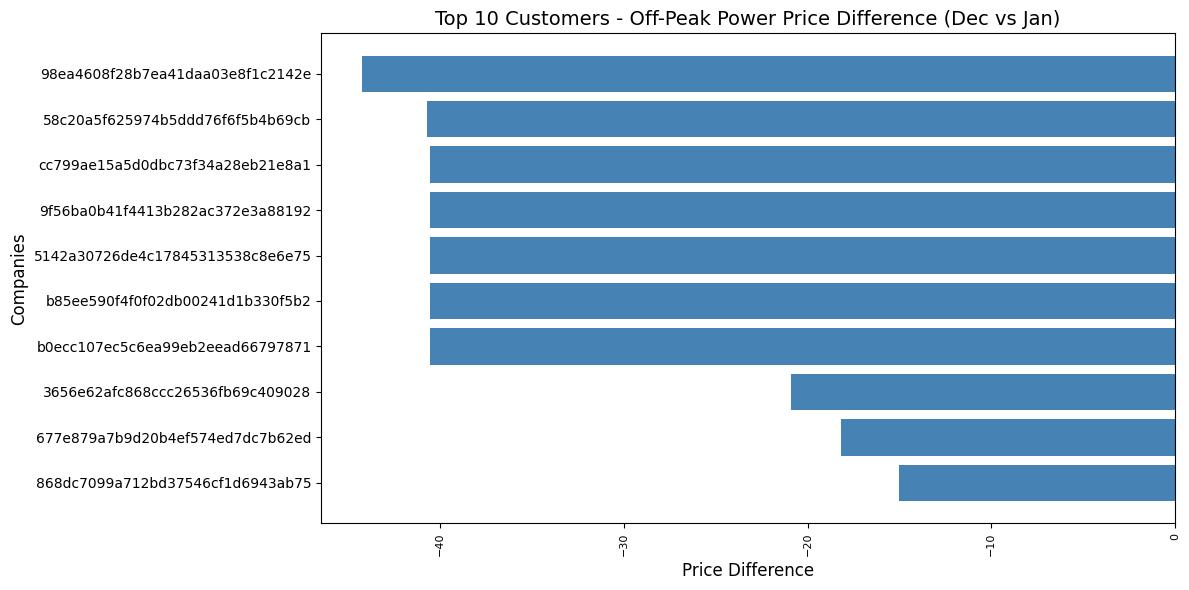

In [31]:
# Top 10 customers by highest energy price difference
top10 = diff_df.nsmallest(10, 'offpeak_diff_dec_jan_power').sort_values('offpeak_diff_dec_jan_power', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top10['id'], top10['offpeak_diff_dec_jan_power'], color='steelblue')

ax.set_title('Top 10 Customers - Off-Peak Power Price Difference (Dec vs Jan)', fontsize=14)
ax.set_xlabel('Price Difference', fontsize=12)
ax.set_ylabel('Companies', fontsize=12)
ax.tick_params(axis='x', labelsize=8, rotation=90)

plt.tight_layout()
plt.show()

In [42]:
df = pd.merge(client_df, diff_df, on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn,offpeak_diff_dec_jan_energy,offpeak_diff_dec_jan_power
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,0.020057,3.700961
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,-0.003767,0.177779
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,-0.004670,0.177779
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,-0.004547,0.177779
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,-0.006192,0.162916


### Average Price Ranges across Period

In [43]:
# Aggregate average prices per period by company
mean_prices = price_df.groupby(['id']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'    
}).reset_index()
mean_prices.head()

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000


In [44]:
# Calculate the mean difference between consecutive periods
mean_prices['off_peak_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_peak_var']
mean_prices['peak_mid_peak_var_mean_diff'] = mean_prices['price_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_mid_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_peak_fix']
mean_prices['peak_mid_peak_fix_mean_diff'] = mean_prices['price_peak_fix'] - mean_prices['price_mid_peak_fix']
mean_prices['off_peak_mid_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_mid_peak_fix']

In [45]:
columns = [
    'id',
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff',
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff',
    'peak_mid_peak_fix_mean_diff',
    'off_peak_mid_peak_fix_mean_diff'
]

df = pd.merge(df, mean_prices[columns], on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,pow_max,churn,offpeak_diff_dec_jan_energy,offpeak_diff_dec_jan_power,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,43.648,1,0.020057,3.700961,0.024038,0.034219,0.058257,18.590255,7.450670,26.040925
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,13.800,0,-0.003767,0.177779,0.142485,0.007124,0.149609,44.311375,0.000000,44.311375
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,13.856,0,-0.004670,0.177779,0.082090,0.088421,0.170512,44.385450,0.000000,44.385450
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,13.200,0,-0.004547,0.177779,0.151210,0.000000,0.151210,44.400265,0.000000,44.400265
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,19.800,0,-0.006192,0.162916,0.020536,0.030773,0.051309,16.275263,8.137629,24.412893


### Max Price Changes across Periods and Months

In [46]:
# Calculate maximum monthly difference across periods
max_prices = mean_prices.groupby(['id']).agg({
    'off_peak_peak_var_mean_diff': 'max',
    'peak_mid_peak_var_mean_diff': 'max',
    'off_peak_mid_peak_var_mean_diff': 'max',
    'off_peak_peak_fix_mean_diff': 'max',
    'peak_mid_peak_fix_mean_diff': 'max',
    'off_peak_mid_peak_fix_mean_diff': 'max'    
}).reset_index().rename(
    columns={
        'off_peak_peak_var_mean_diff': 'off_peak_peak_var_max_diff',
        'peak_mid_peak_var_mean_diff': 'peak_mid_peak_var_max_diff',
        'off_peak_mid_peak_var_mean_diff': 'off_peak_mid_peak_var_max_diff',
        'off_peak_peak_fix_mean_diff': 'off_peak_peak_fix_max_diff',
        'peak_mid_peak_fix_mean_diff': 'peak_mid_peak_fix_max_diff',
        'off_peak_mid_peak_fix_mean_diff': 'off_peak_mid_peak_fix_max_diff'
    }
)
max_prices.head()

,id,off_peak_peak_var_max_diff,peak_mid_peak_var_max_diff,off_peak_mid_peak_var_max_diff,off_peak_peak_fix_max_diff,peak_mid_peak_fix_max_diff,off_peak_mid_peak_fix_max_diff
0,0002203ffbb812588b632b9e628cc38d,0.020545,0.030633,0.051178,16.280694,8.140345,24.421038
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.146426,44.385450,0.000000,44.385450
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.181558,45.319710,0.000000,45.319710
3,0010ee3855fdea87602a5b7aba8e42de,0.020465,0.029260,0.049725,16.258972,8.129484,24.388456
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.147926,44.266930,0.000000,44.266930


In [47]:
columns = [
    'id',
    'off_peak_peak_var_max_diff',
    'peak_mid_peak_var_max_diff',
    'off_peak_mid_peak_var_max_diff',
    'off_peak_peak_fix_max_diff',
    'peak_mid_peak_fix_max_diff',
    'off_peak_mid_peak_fix_max_diff'
]

df = pd.merge(df, max_prices[columns], on='id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff,off_peak_peak_var_max_diff,peak_mid_peak_var_max_diff,off_peak_mid_peak_var_max_diff,off_peak_peak_fix_max_diff,peak_mid_peak_fix_max_diff,off_peak_mid_peak_fix_max_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.058257,18.590255,7.450670,26.040925,0.024038,0.034219,0.058257,18.590255,7.450670,26.040925
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.149609,44.311375,0.000000,44.311375,0.142485,0.007124,0.149609,44.311375,0.000000,44.311375
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.170512,44.385450,0.000000,44.385450,0.082090,0.088421,0.170512,44.385450,0.000000,44.385450
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.151210,44.400265,0.000000,44.400265,0.151210,0.000000,0.151210,44.400265,0.000000,44.400265
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.051309,16.275263,8.137629,24.412893,0.020536,0.030773,0.051309,16.275263,8.137629,24.412893


Calculating the maximum price change between months and time periods could be a good feature to create because customers might be more likely to churn if they experience sudden large price changes.

### 2. Further Feature Engineering
Tenure:

In [49]:
df['tenure'] = (df['date_end'] - df['date_activ']).dt.days // 365
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff,off_peak_peak_var_max_diff,peak_mid_peak_var_max_diff,off_peak_mid_peak_var_max_diff,off_peak_peak_fix_max_diff,peak_mid_peak_fix_max_diff,off_peak_mid_peak_fix_max_diff,tenure
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,18.590255,7.450670,26.040925,0.024038,0.034219,0.058257,18.590255,7.450670,26.040925,3
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,44.311375,0.000000,44.311375,0.142485,0.007124,0.149609,44.311375,0.000000,44.311375,7
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,44.385450,0.000000,44.385450,0.082090,0.088421,0.170512,44.385450,0.000000,44.385450,6
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,44.400265,0.000000,44.400265,0.151210,0.000000,0.151210,44.400265,0.000000,44.400265,6
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,16.275263,8.137629,24.412893,0.020536,0.030773,0.051309,16.275263,8.137629,24.412893,6


In [83]:
count_churn_by_tenure = df.groupby([df['tenure'], df['churn']])['id'].count().unstack(level=1)
percent_churn_by_tenure = (count_churn_by_tenure.div(count_churn_by_tenure.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
percent_churn_by_tenure.sort_values(by=['tenure'], ascending=True)

churn,0,1
tenure,,
2,82.352941,17.647059
3,85.612648,14.387352
4,87.252747,12.747253
5,90.800141,9.199859
6,92.459297,7.540703
7,92.452830,7.547170
8,95.275591,4.724409
9,98.750000,1.250000
10,95.454545,4.545455


We can see that companies who have only been a client for 4 or less months are much more likely to churn compared to companies that have been a client for longer. Interestingly, the difference between 4 and 5 months is about 4%, which represents a large jump in likelihood for a customer to churn compared to the other differences between ordered tenure values. Perhaps this reveals that getting a customer to over 4 months tenure is actually a large milestone with respect to keeping them as a long term customer. 

### Transforming Dates into Months
- reference date = Jan 2016
- months_activ = Number of months active until reference date 
- months_to_end = Number of months of the contract left until reference date
- months_modif_prod = Number of months since last modification until reference date
- months_renewal = Number of months since last renewal until reference date

In [84]:
def convert_months(reference_date, df, column):
    dates = pd.to_datetime(df[column])
    year_diff = reference_date.year - dates.dt.year
    month_diff = reference_date.month - dates.dt.month
    # month count
    months = year_diff * 12 + month_diff
    # subtract 1 if reference date hasn't been reached yet
    months -= (reference_date.day < dates.dt.day).astype(int)

    return months

In [86]:
# Create reference date
reference_date = datetime(2016, 1, 1)

# Create columns
df['months_activ'] = convert_months(reference_date, df, 'date_activ')
df['months_to_end'] = -convert_months(reference_date, df, 'date_end')
df['months_modif_prod'] = convert_months(reference_date, df, 'date_modif_prod')
df['months_renewal'] = convert_months(reference_date, df, 'date_renewal')

In [87]:
remove = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
]

df = df.drop(columns=remove)
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,...,peak_mid_peak_var_max_diff,off_peak_mid_peak_var_max_diff,off_peak_peak_fix_max_diff,peak_mid_peak_fix_max_diff,off_peak_mid_peak_fix_max_diff,tenure,months_activ,months_to_end,months_modif_prod,months_renewal
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,...,0.034219,0.058257,18.590255,7.450670,26.040925,3,30,6,2,6
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,189.95,0,0.0,16.27,0.145711,...,0.007124,0.149609,44.311375,0.000000,44.311375,7,76,8,76,4
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,...,0.088421,0.170512,44.385450,0.000000,44.385450,6,68,4,68,8
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,...,0.000000,0.151210,44.400265,0.000000,44.400265,6,69,3,69,9
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,445.75,526,0.0,131.73,0.116900,...,0.030773,0.051309,16.275263,8.137629,24.412893,6,71,3,71,9


### Transform Has Gas

In [88]:
df['has_gas'] = df['has_gas'].replace(['t', 'f'], [1, 0])
df.groupby(['has_gas']).agg({'churn': 'mean'})

,churn
has_gas,
0,0.100544
1,0.081856


Customers who buy multiple products from PowerCo may have higher switching costs, and therefore could be more loyal. Given that customers who buy gas are 2% less likely to churn.

### Random Forest
Map categories containing strings to an integer (label encoding) using dummy variables (hot encoding). Categories that show up less than 100 times will be eliminated.
### channel_sales and origin_up

In [89]:
cols = ['channel_sales', 'origin_up']
min_count = 100

# get counts per category so we can filter out rare categories
value_counts = {col: df[col].value_counts() for col in cols}

df = pd.get_dummies(df, columns=cols, prefix=cols, dtype=int)

# drop rare columns
for col in cols:
    keep_cols = set(value_counts[col][value_counts[col] >= min_count].index.astype(str))

    dummy_cols = [c for c in df.columns if c.startswith(f"{col}_")]
    drop_cols = [c for c in dummy_cols if c.split(f"{col}_", 1)[1] not in keep_cols]
    df.drop(columns=drop_cols, inplace=True)

### Transforming Numerical Data

In [90]:
skewed_cols = [
    'cons_12m', 
    'cons_gas_12m', 
    'cons_last_month',
    'forecast_cons_12m', 
    'forecast_cons_year', 
    'forecast_discount_energy',
    'forecast_meter_rent_12m', 
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak', 
    'forecast_price_pow_off_peak'
]

print("Before log transform:")
print(df[skewed_cols].describe())

df[skewed_cols] = np.log10(df[skewed_cols] + 1)

print("After log transform:")
print(df[skewed_cols].describe())

Before log transform:
           cons_12m  cons_gas_12m  cons_last_month  forecast_cons_12m  \
count  1.460600e+04  1.460600e+04     14606.000000       14606.000000   
mean   1.592203e+05  2.809238e+04     16090.269752        1868.614880   
std    5.734653e+05  1.629731e+05     64364.196422        2387.571531   
min    0.000000e+00  0.000000e+00         0.000000           0.000000   
25%    5.674750e+03  0.000000e+00         0.000000         494.995000   
50%    1.411550e+04  0.000000e+00       792.500000        1112.875000   
75%    4.076375e+04  0.000000e+00      3383.000000        2401.790000   
max    6.207104e+06  4.154590e+06    771203.000000       82902.830000   

       forecast_cons_year  forecast_discount_energy  forecast_meter_rent_12m  \
count        14606.000000              14606.000000             14606.000000   
mean          1399.762906                  0.966726                63.086871   
std           3247.786255                  5.108289                66.165783   


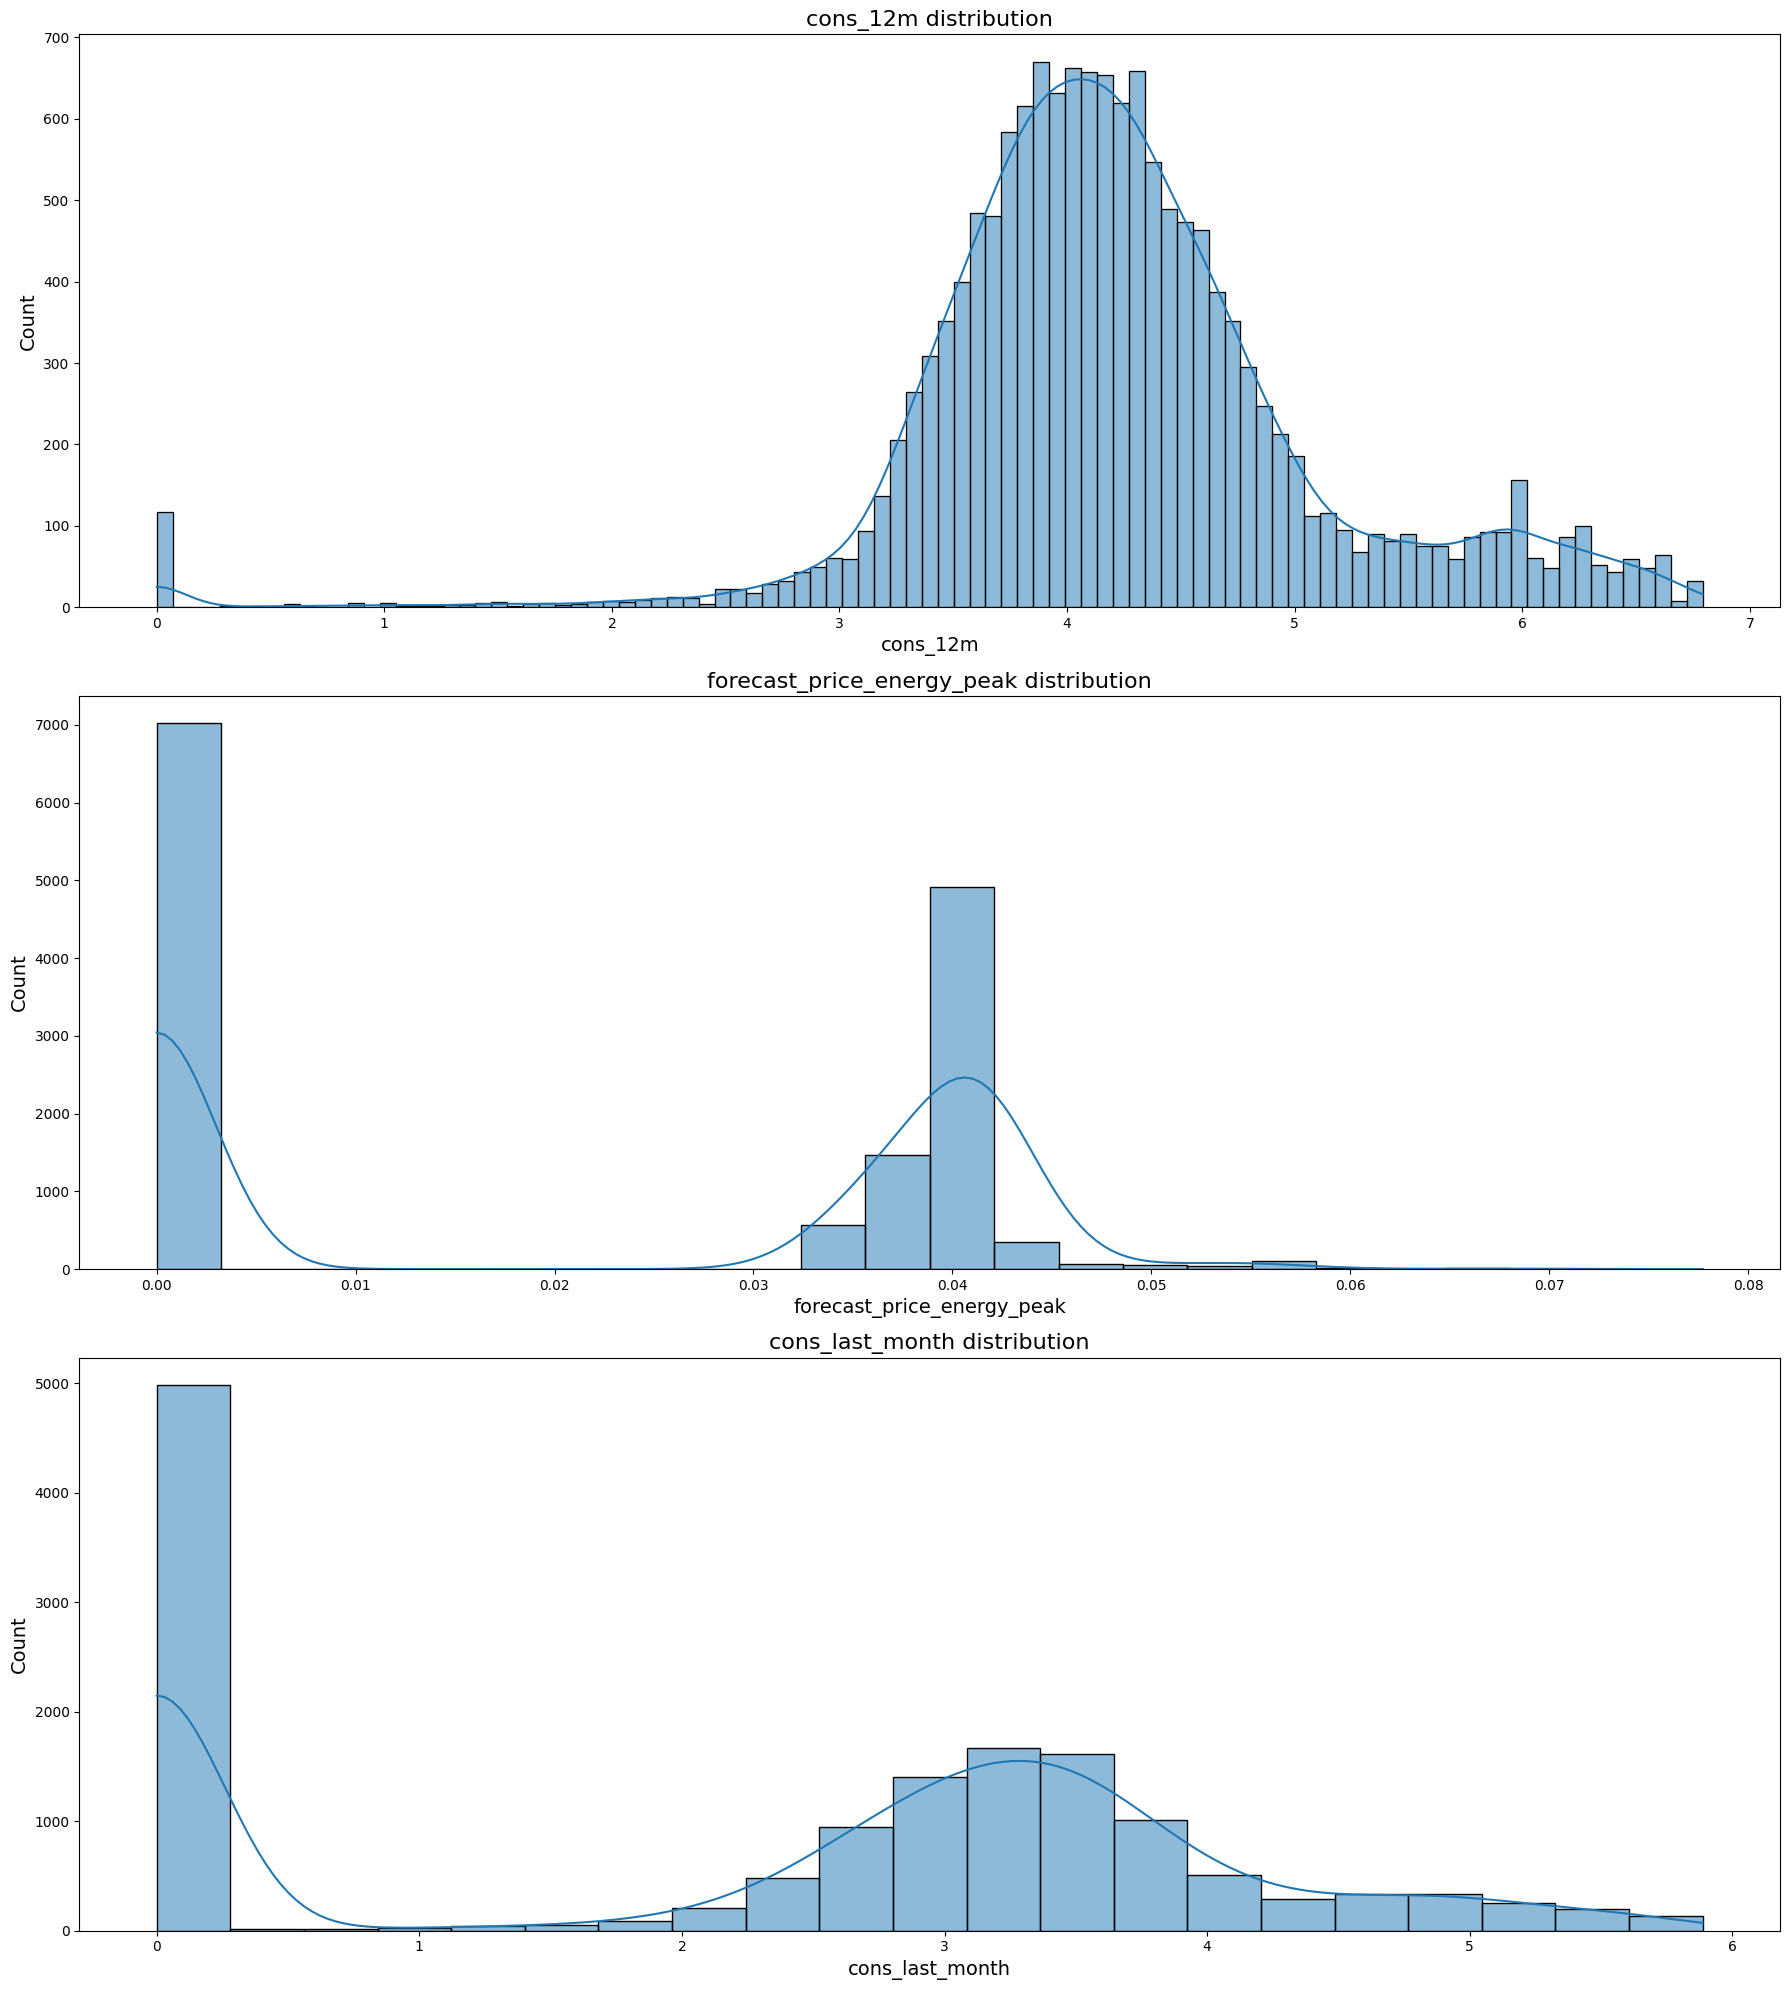

In [91]:
# Distribution plot
cols = ['cons_12m', 'forecast_price_energy_peak', 'cons_last_month']

# Set subplots
fig, axs = plt.subplots(nrows=len(cols), figsize=(18,20))

# Loop through each column
for ax, col in zip(axs, cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} distribution", fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

plt.tight_layout()
plt.show()

In [92]:
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_sales_MISSING,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.000000,0.0,1.237292,0.059075,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.000000,0.0,1.599009,0.066622,0.036589,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.000000,0.0,1.318689,0.059448,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,2.721811,0.0,2.122969,0.048014,0.041399,...,71,9,1,0,0,0,0,1,0,0


### Correlations
Creating new featuers requires trial and error and requires iteration. Checking the correlation between new features with target variable of interest. Check if features are highly correlated with each other (and leave only one in the model), since predictive models work best when the features are uncorrelated.

In [93]:
correlation = df.drop(columns=['id']).corr()

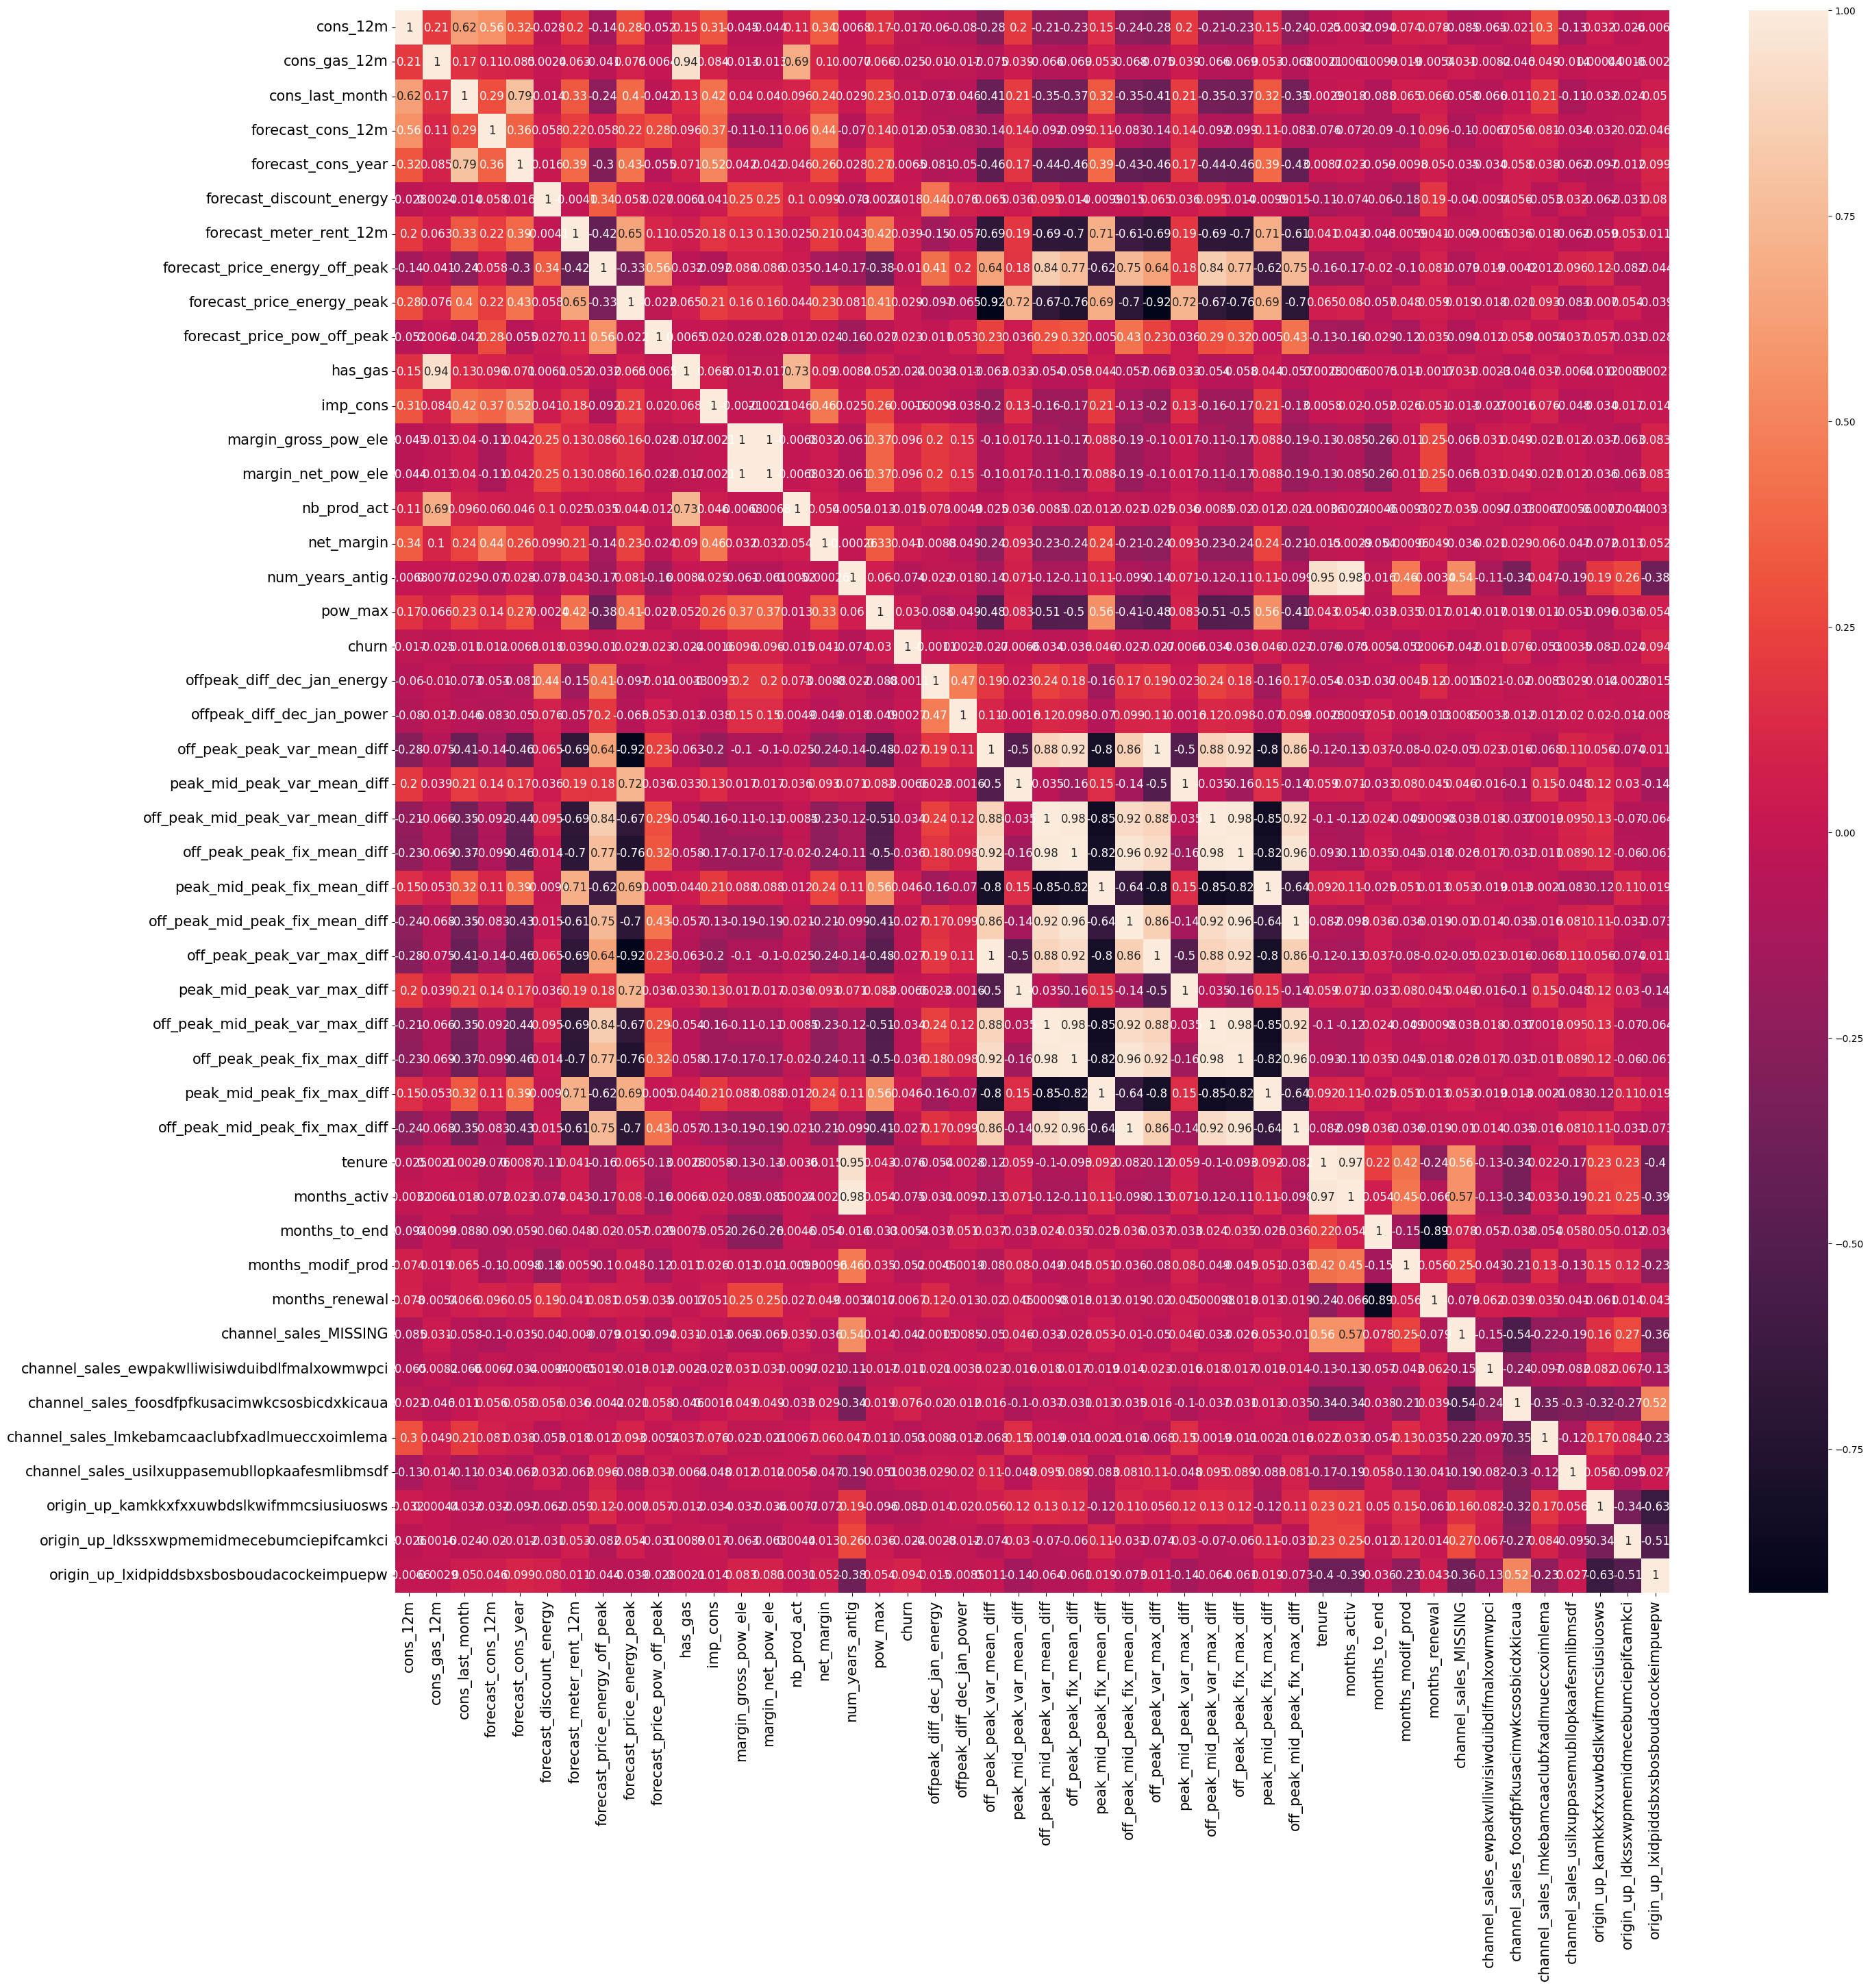

In [97]:
# Plot correlation
plt.figure(figsize=(30,30))
sns.heatmap(
    correlation,
    xticklabels = correlation.columns.values,
    yticklabels = correlation.columns.values,
    annot=True,
    annot_kws={'size': 12}
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

In [96]:
df = df.drop(columns=['num_years_antig', 'forecast_cons_year'])
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_sales_MISSING,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,1.619163,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.059075,0.000000,1.656207,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.066622,0.036589,1.656207,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.059448,0.000000,1.656207,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.048014,0.041399,1.619163,...,71,9,1,0,0,0,0,1,0,0


### 3. Modelling

In [98]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [99]:
# Make a copy of the data
train_df = df.copy()

# Split target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 43)
(14606,)


In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 43)
(10954,)
(3652, 43)
(3652,)


### Random Forest

In [115]:
model = RandomForestClassifier(
    n_estimators=1200,
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

Using 3 metrics to evaluate performance:

- Accuracy = the ratio of correctly predicted observations to the total observations
- Precision = the ability of the classifier to not label a negative sample as positive
- Recall = the ability of the classifier to find all the positive samples


In [116]:
predictions = model.predict(X_test)
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()
print(y_test.value_counts())

churn
0    3286
1     366
Name: count, dtype: int64


In [117]:
print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"True negatives: {tn}")
print(f"False negatives: {fn}\n")

print(f"Accuracy: {metrics.accuracy_score(y_test, predictions)}")
print(f"Precision: {metrics.precision_score(y_test, predictions)}")
print(f"Recall: {metrics.recall_score(y_test, predictions)}")
print(f"F1 Score: {metrics.f1_score(y_test, predictions)}")  

True positives: 19
False positives: 2
True negatives: 3284
False negatives: 347

Accuracy: 0.9044359255202629
Precision: 0.9047619047619048
Recall: 0.05191256830601093
F1 Score: 0.09819121447028424


### Feature Importance Evaluation

In [ ]:
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importances': model.feature_importances
}).sort_values(by='importances', ascending=True).reset_index()

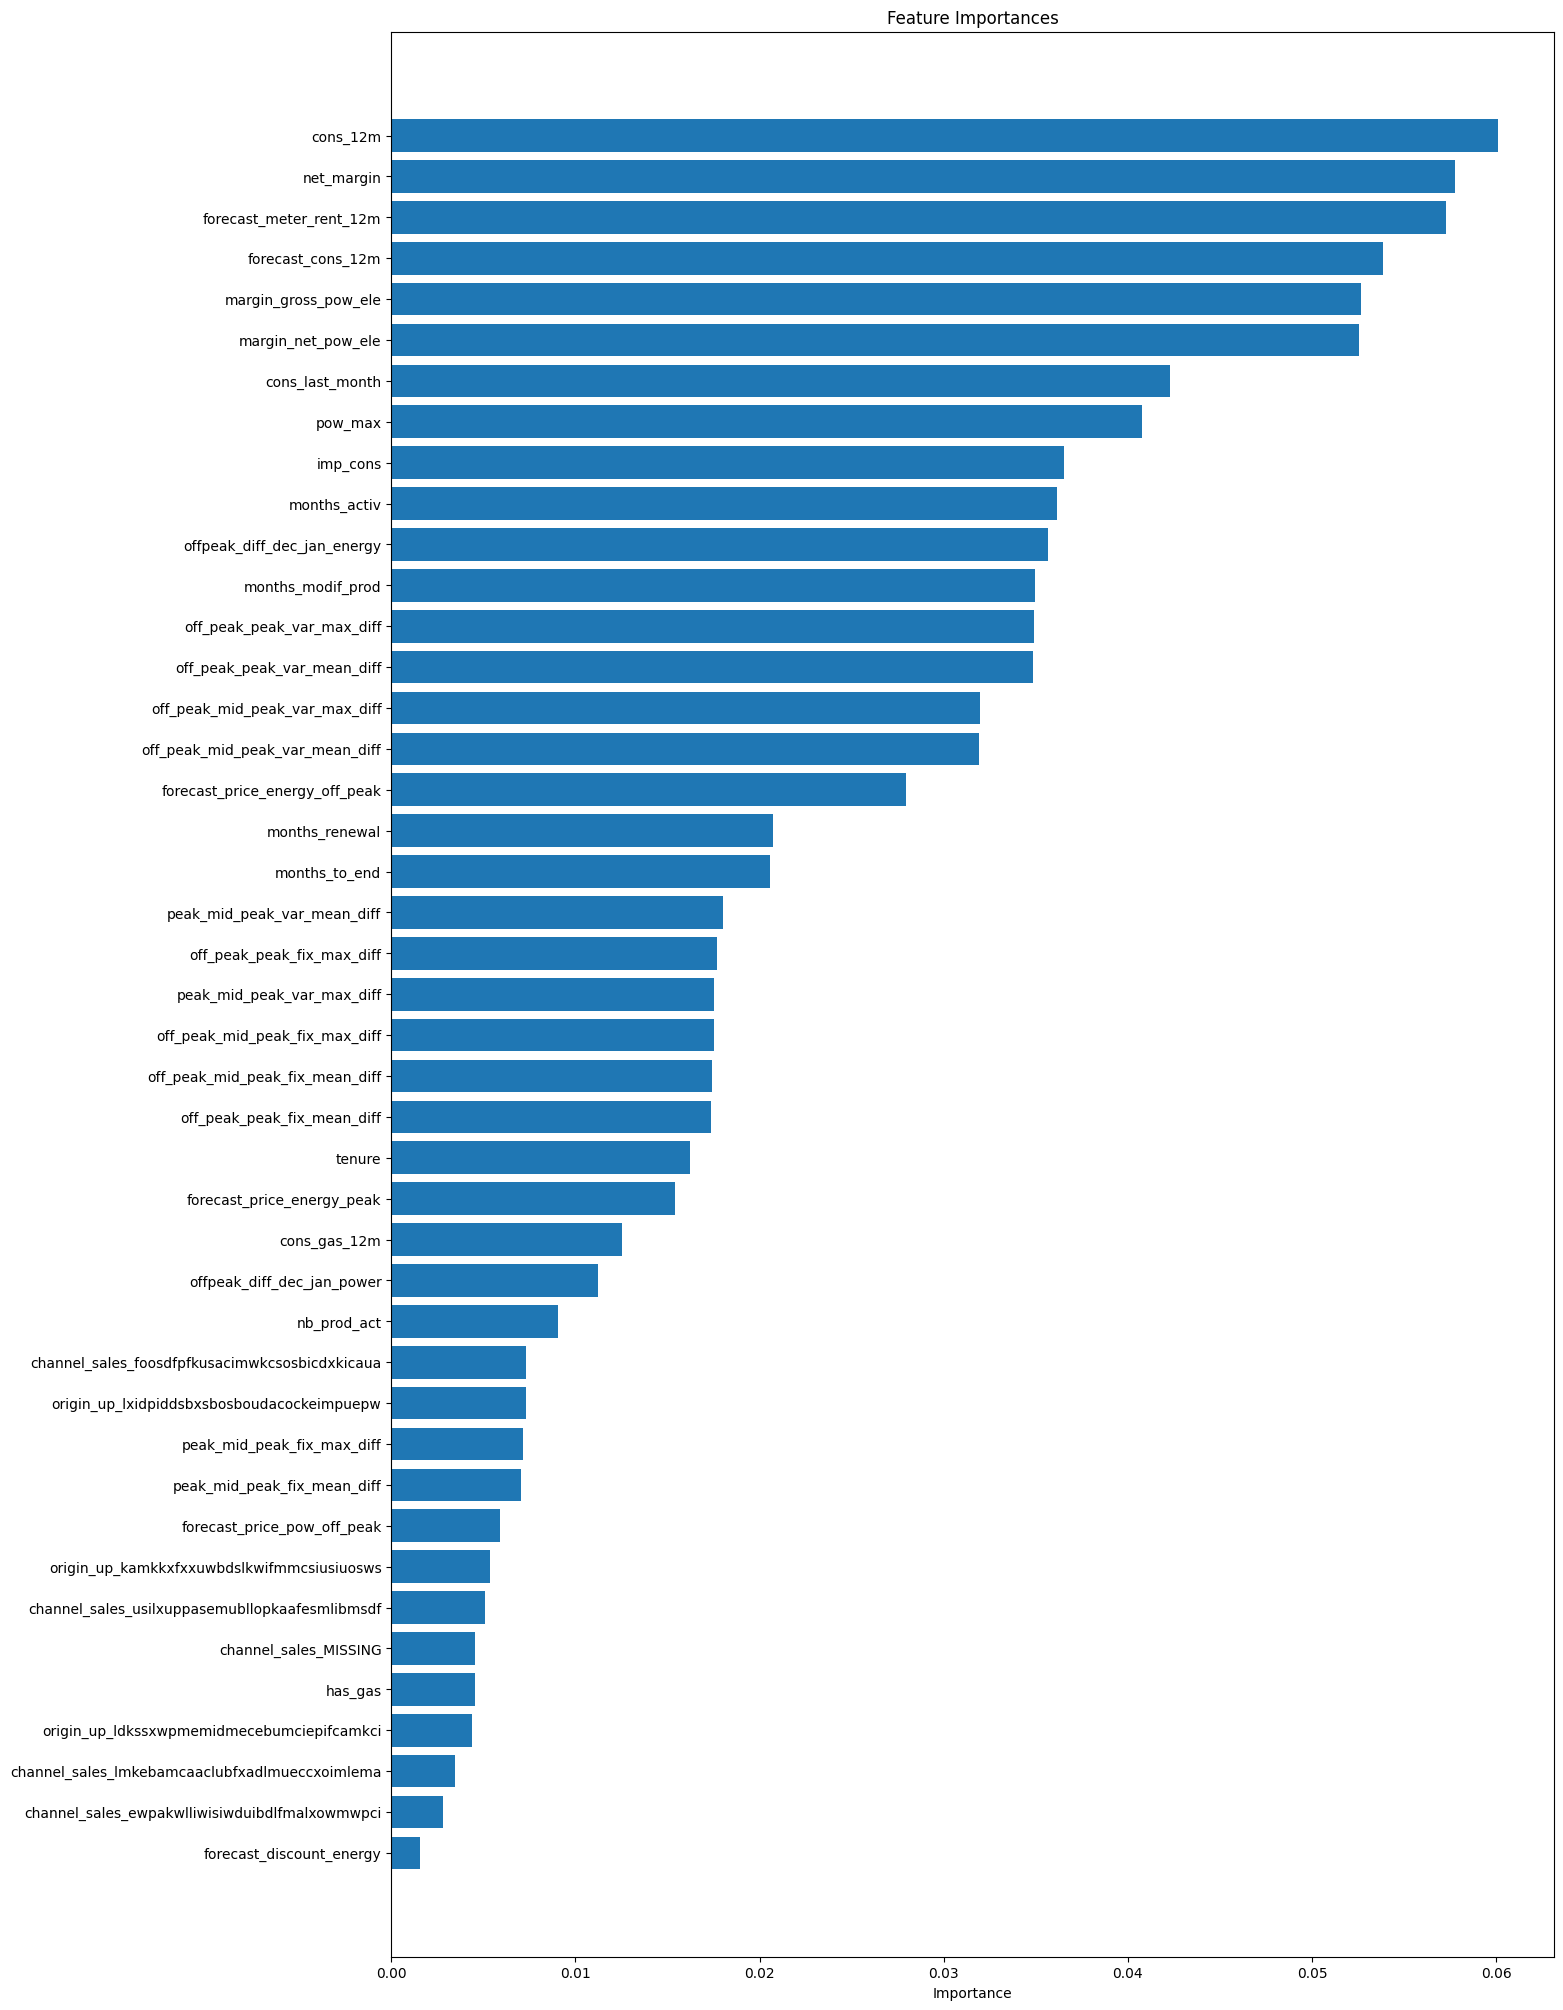

In [125]:
plt.figure(figsize=(15, 25))
plt.title('Feature Importances')
plt.barh(range(len(feature_importances)), feature_importances['importances'], align='center')
plt.yticks(range(len(feature_importances)), feature_importances['features'])
plt.xlabel('Importance')
plt.show()

### Summary points:

- Net margin and consumption over 12 months is a top driver for clients' churn 
- Margin gross and net for power subscription is also an influential driver
- Time seems to be an influential factor, especially the number of months they have been active, their tenure and the number of months since they updated their contract
- The feature that recommended is in the top half in terms of how influential it is and some of the features built off the back of this actually outperform it
- Our price sensitivity features are scattered around but are not the main driver for a customer churning

The last observation is important because this relates back to the original hypothesis:

> "Is churn driven by the customers' price sensitivity?"

Based on the output of the feature importances, it is not a main driver but it is a weak contributor. However, to arrive at a conclusive result, more experimentation is needed.

In [126]:
proba_predictions = model.predict_proba(X_test)
probabilities = proba_predictions[:, 1]

In [127]:
X_test = X_test.reset_index()
X_test.drop(columns='index', inplace=True)

In [128]:
X_test['churn'] = predictions.tolist()
X_test['churn_probability'] = probabilities.tolist()
X_test.to_csv('out_of_sample_data_with_predictions.csv')